## Step 1: *Data Exporting & Preparation*

In [21]:
# Step 1a: Import all necessary Python libraries for project analysis.

import pandas as pd
# import numpy as np # might not be necessary, to remove later if not
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import export_graphviz
import graphviz
import warnings #For removing warning messages which is not important
warnings.filterwarnings('ignore')
sb.set() # to set the default Seaborn style for graphics

In [22]:
# Step 1b: Dataset in CSV form is imported.

dbt = pd.read_csv('diabetic_data.csv')

# Step 1c: Look at the data.

dbt.head() # to briefly see what the dataset looks like

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [23]:
dbt.info() # list of all columns and info about numbers and datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [24]:
# Step 1d: We can drop some columns that we know will be out of scope.

dbt_df = dbt.copy() # copy original data in a new dataframe so we don't accidentally corrupt anything.
dbt_df = dbt_df.drop(dbt_df.columns[[0,1,6,7,8,10,11,18,19,20,22,23]], axis=1) # removing 9 columns based on scope
dbt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    101766 non-null  object
 4   time_in_hospital          101766 non-null  int64 
 5   num_lab_procedures        101766 non-null  int64 
 6   num_procedures            101766 non-null  int64 
 7   num_medications           101766 non-null  int64 
 8   number_outpatient         101766 non-null  int64 
 9   number_emergency          101766 non-null  int64 
 10  number_inpatient          101766 non-null  int64 
 11  number_diagnoses          101766 non-null  int64 
 12  metformin                 101766 non-null  object
 13  repaglinide               101766 non-null  object
 14  nate

In [26]:
# Step 1e: Changing object datatypes to categorical
object_cols = dbt_df.select_dtypes(include=['object']).columns
dbt_df[object_cols] = dbt_df[object_cols].astype('category')
dbt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   race                      101766 non-null  category
 1   gender                    101766 non-null  category
 2   age                       101766 non-null  category
 3   weight                    101766 non-null  category
 4   time_in_hospital          101766 non-null  int64   
 5   num_lab_procedures        101766 non-null  int64   
 6   num_procedures            101766 non-null  int64   
 7   num_medications           101766 non-null  int64   
 8   number_outpatient         101766 non-null  int64   
 9   number_emergency          101766 non-null  int64   
 10  number_inpatient          101766 non-null  int64   
 11  number_diagnoses          101766 non-null  int64   
 12  metformin                 101766 non-null  category
 13  repaglinide               101

In [27]:
# Step 1f: Based on our problem statement,converting Readmitted to Yes ('<30'& '>30') and No ('No') 
dbt_dfplot = dbt_df.copy()
dbt_dfplot['readmitted'] = dbt_dfplot['readmitted'].replace({'<30': 'Yes', '>30': 'Yes', 'NO': 'No'}) # if we only care about Readmitted
dbt_dfplot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   race                      101766 non-null  category
 1   gender                    101766 non-null  category
 2   age                       101766 non-null  category
 3   weight                    101766 non-null  category
 4   time_in_hospital          101766 non-null  int64   
 5   num_lab_procedures        101766 non-null  int64   
 6   num_procedures            101766 non-null  int64   
 7   num_medications           101766 non-null  int64   
 8   number_outpatient         101766 non-null  int64   
 9   number_emergency          101766 non-null  int64   
 10  number_inpatient          101766 non-null  int64   
 11  number_diagnoses          101766 non-null  int64   
 12  metformin                 101766 non-null  category
 13  repaglinide               101

#### Important: Our Final clean file has a name of dbt_dfplot

## Step 2: *Exploratory Analysis*
The univariate exploratory analysis are done separately for Numerical and Catergorical Data set. This is followed by their multi-variate analysis against our target variable "Readmitted"


### Numerical (Uni-variate)


In [28]:
# Creating the separate data framework for all the int64 datatype variables
dbt_dfplot.select_dtypes(include='int64').describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


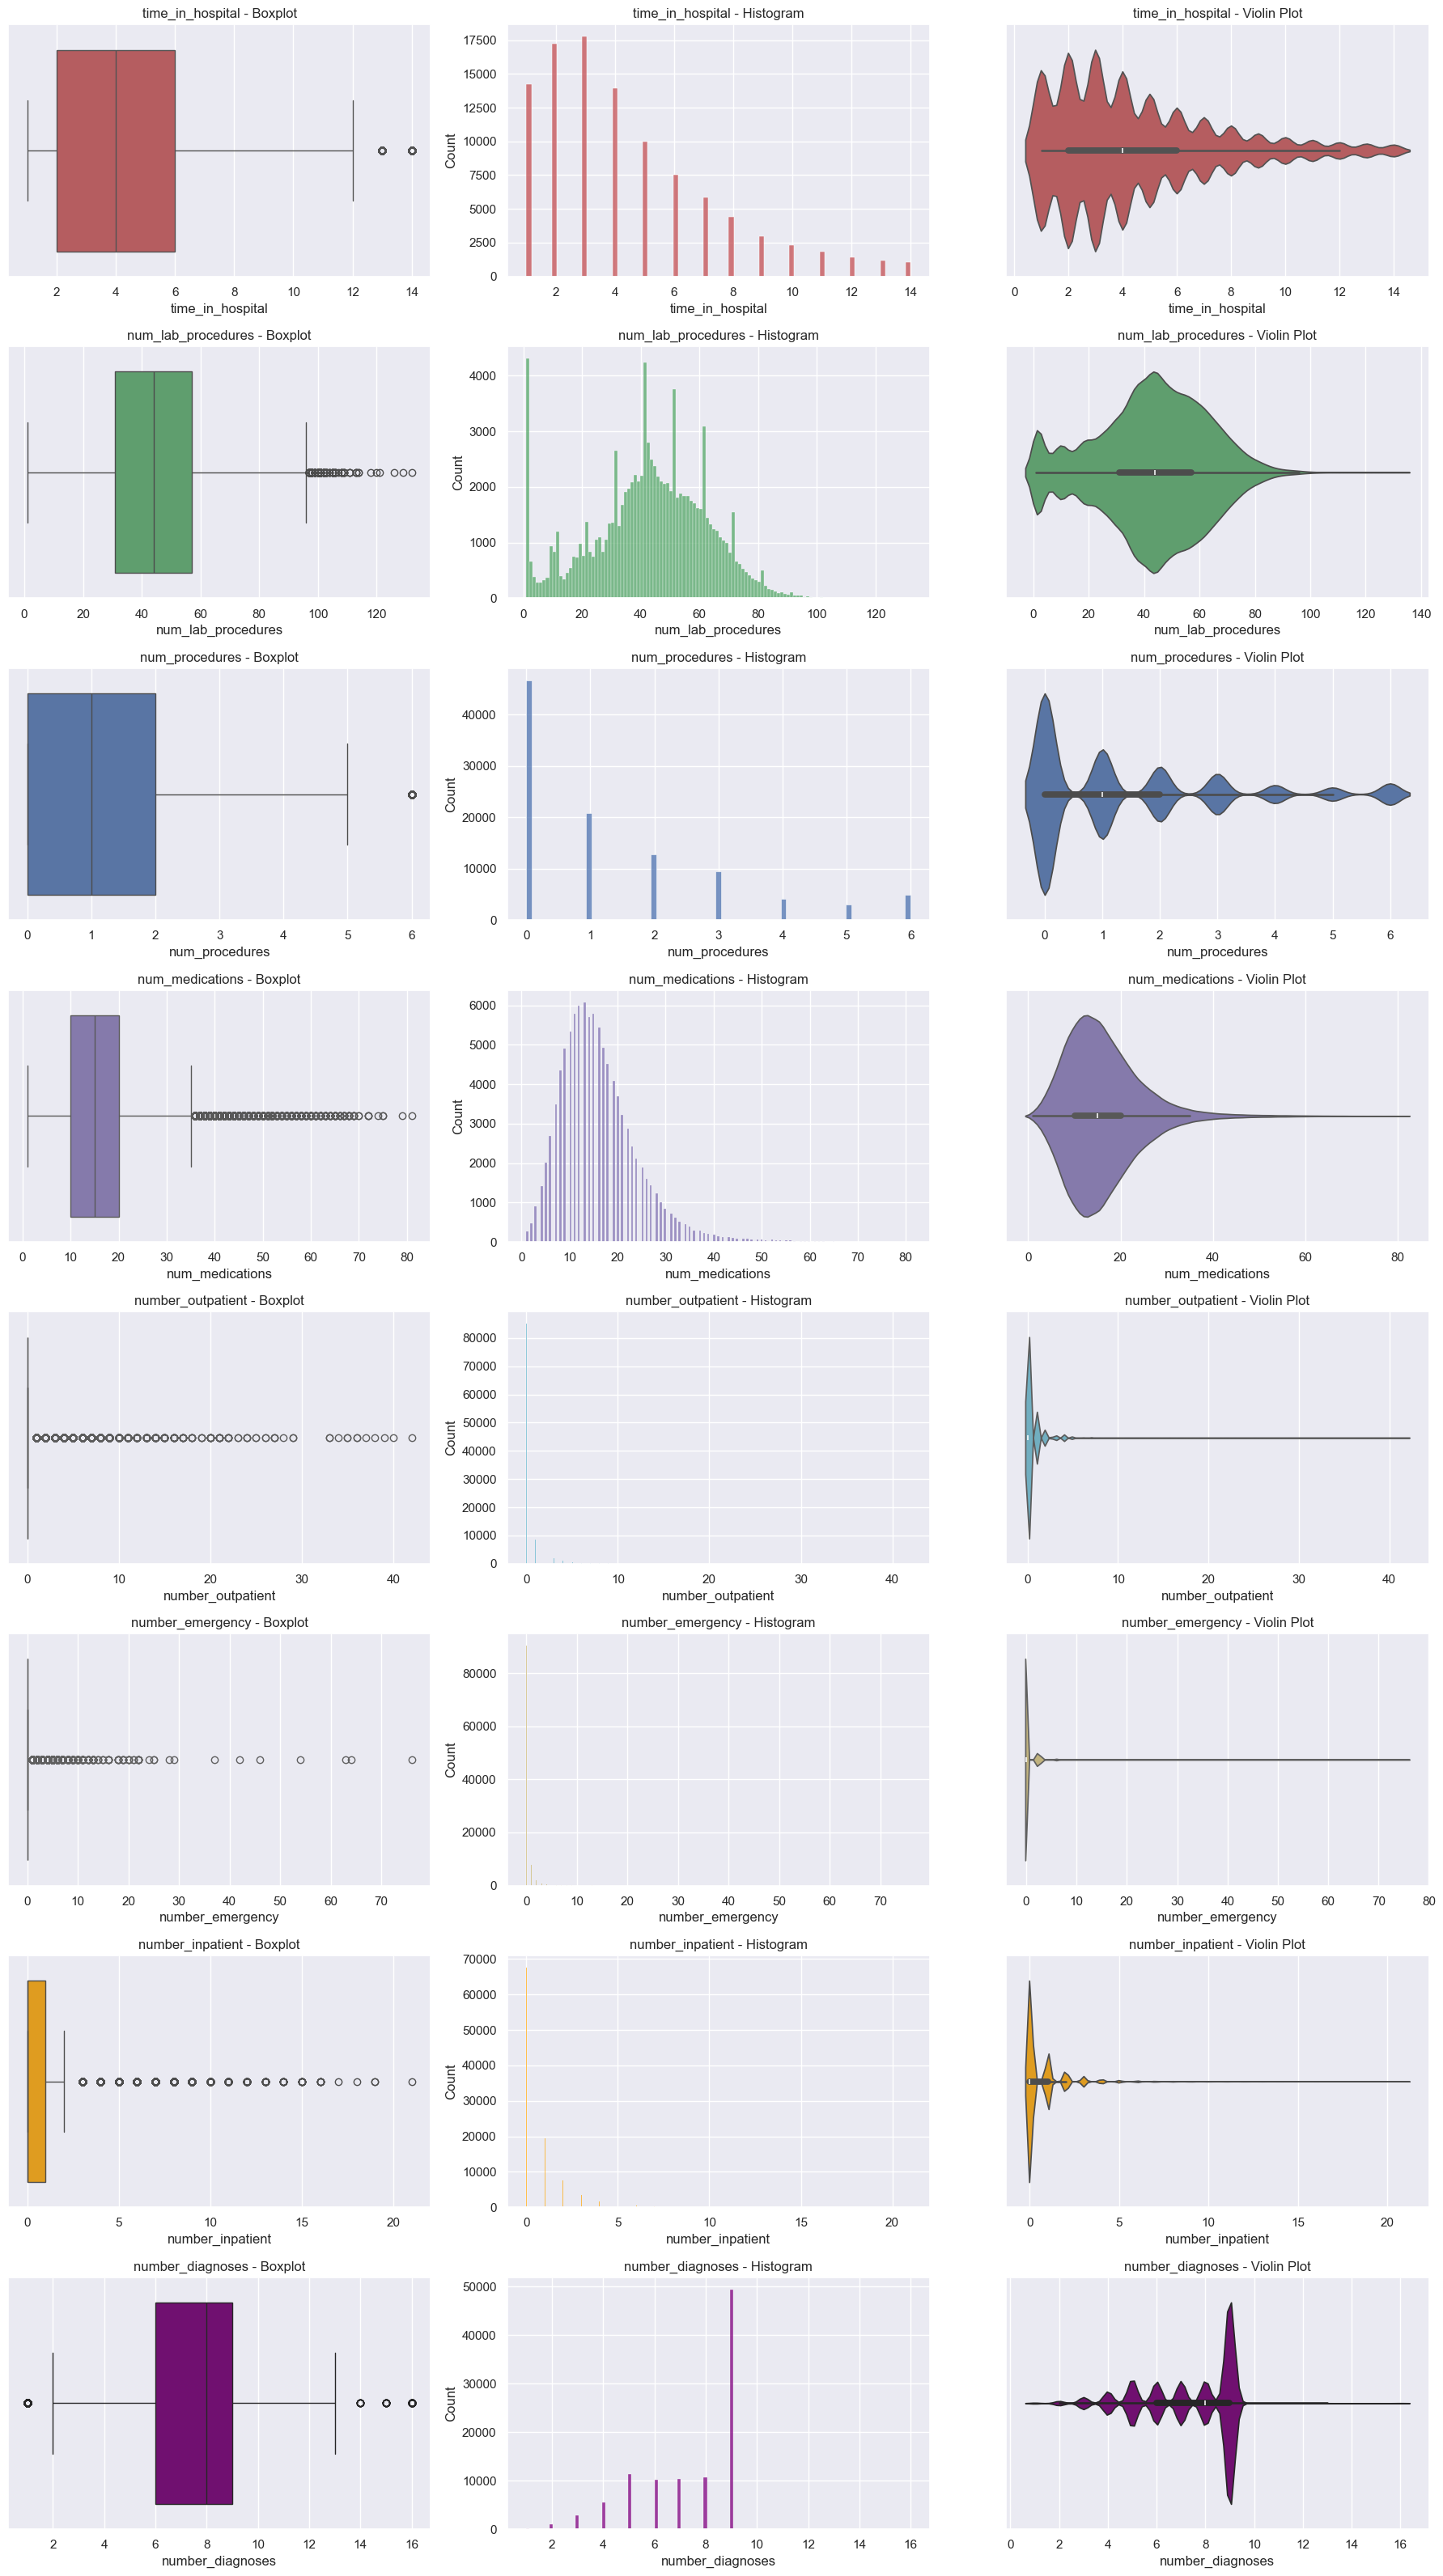

In [29]:
# Plotting the boxplot, histplot, violinplot for all the numerical data 
numerical_cols = dbt_dfplot.select_dtypes(include='int64').columns.tolist() # to get number of columns as a value- it will come handy when specifiying the size of figure

f, axes = plt.subplots(len(numerical_cols), 3, figsize=(18, len(numerical_cols)*4))
colors = ["r", "g", "b", "m", "c", "y", "orange", "purple"]
count = 0

for var in numerical_cols:
    sb.boxplot(x=var, data=dbt_dfplot, color=colors[count % len(colors)], ax=axes[count, 0])
    axes[count, 0].set_title(f'{var} - Boxplot')
    
    sb.histplot(x=var, data=dbt_dfplot, color=colors[count % len(colors)], ax=axes[count, 1])
    axes[count, 1].set_title(f'{var} - Histogram')
    
    sb.violinplot(x=var, data=dbt_dfplot, color=colors[count % len(colors)], ax=axes[count, 2])
    axes[count, 2].set_title(f'{var} - Violin Plot')
    
    count += 1

plt.tight_layout()
plt.show()

#### Analysis: Numerical (Uni-variate)
No.of outpatient and no. of emergency are highly skewed.

### Categorical (Uni-variate)


In [9]:
# First using the describe function on the categorical data
dbt_categorical = dbt_dfplot.select_dtypes(include='category').copy()

print(dbt_categorical.shape)
print(dbt_categorical.columns.tolist())
dbt_categorical.head()
dbt_categorical.describe()

(101766, 30)
['race', 'gender', 'age', 'weight', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,race,gender,age,weight,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,4,4,4,4,4,2,...,1,4,4,2,2,2,2,2,2,2
top,Caucasian,Female,[70-80),?,No,No,No,No,No,No,...,No,No,No,No,No,No,No,No,Yes,No
freq,76099,54708,26068,98569,81778,100227,101063,101680,96575,101765,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


In [10]:
dbt_categorical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 30 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   race                      101766 non-null  category
 1   gender                    101766 non-null  category
 2   age                       101766 non-null  category
 3   weight                    101766 non-null  category
 4   metformin                 101766 non-null  category
 5   repaglinide               101766 non-null  category
 6   nateglinide               101766 non-null  category
 7   chlorpropamide            101766 non-null  category
 8   glimepiride               101766 non-null  category
 9   acetohexamide             101766 non-null  category
 10  glipizide                 101766 non-null  category
 11  glyburide                 101766 non-null  category
 12  tolbutamide               101766 non-null  category
 13  pioglitazone              101

#### Checking the Dominance of each categorical variable using the following formula (Plotting the count plot leads to memory error) 
Dominance = freq/count * 100)
If the dominance ratio is high, then that would indicate that the cat variable is highly skewed and we better off removing it from our final analysis



In [11]:
# Calculating the dominance using the formula stated above
desc = dbt_categorical.describe()


dominance = pd.DataFrame({
    'top_category': desc.loc['top'],
    'freq':         desc.loc['freq'].astype(float),
    'total':        desc.loc['count'].astype(float),
    'dominance_%':  round(desc.loc['freq'].astype(float) / desc.loc['count'].astype(float) * 100, 2)
})

dominance = dominance.sort_values('dominance_%', ascending=False)
dominance

,top_category,freq,total,dominance_%
acetohexamide,No,101765.0,101766.0,100.00
metformin-rosiglitazone,No,101764.0,101766.0,100.00
citoglipton,No,101766.0,101766.0,100.00
examide,No,101766.0,101766.0,100.00
troglitazone,No,101763.0,101766.0,100.00
metformin-pioglitazone,No,101765.0,101766.0,100.00
glimepiride-pioglitazone,No,101765.0,101766.0,100.00
glipizide-metformin,No,101753.0,101766.0,99.99
tolbutamide,No,101743.0,101766.0,99.98
miglitol,No,101728.0,101766.0,99.96


#### Analysis: Categorical (Uni-variate)
To avoid, baisness, it is decided to exclude all the cat variable with the dominance ratio >90% and then consider the rest for their bi-variate analysis with the Readmitted

### Numerical (Bi-Variate)
#### Readmitted against the (shortlisted?? if we exclude the no. of outpatients & no. of emergency then yes) Numerical variables  

If the 'Yes' and 'No' boxes are clearly separated (little overlap), that variable is a strong predictor of readmission

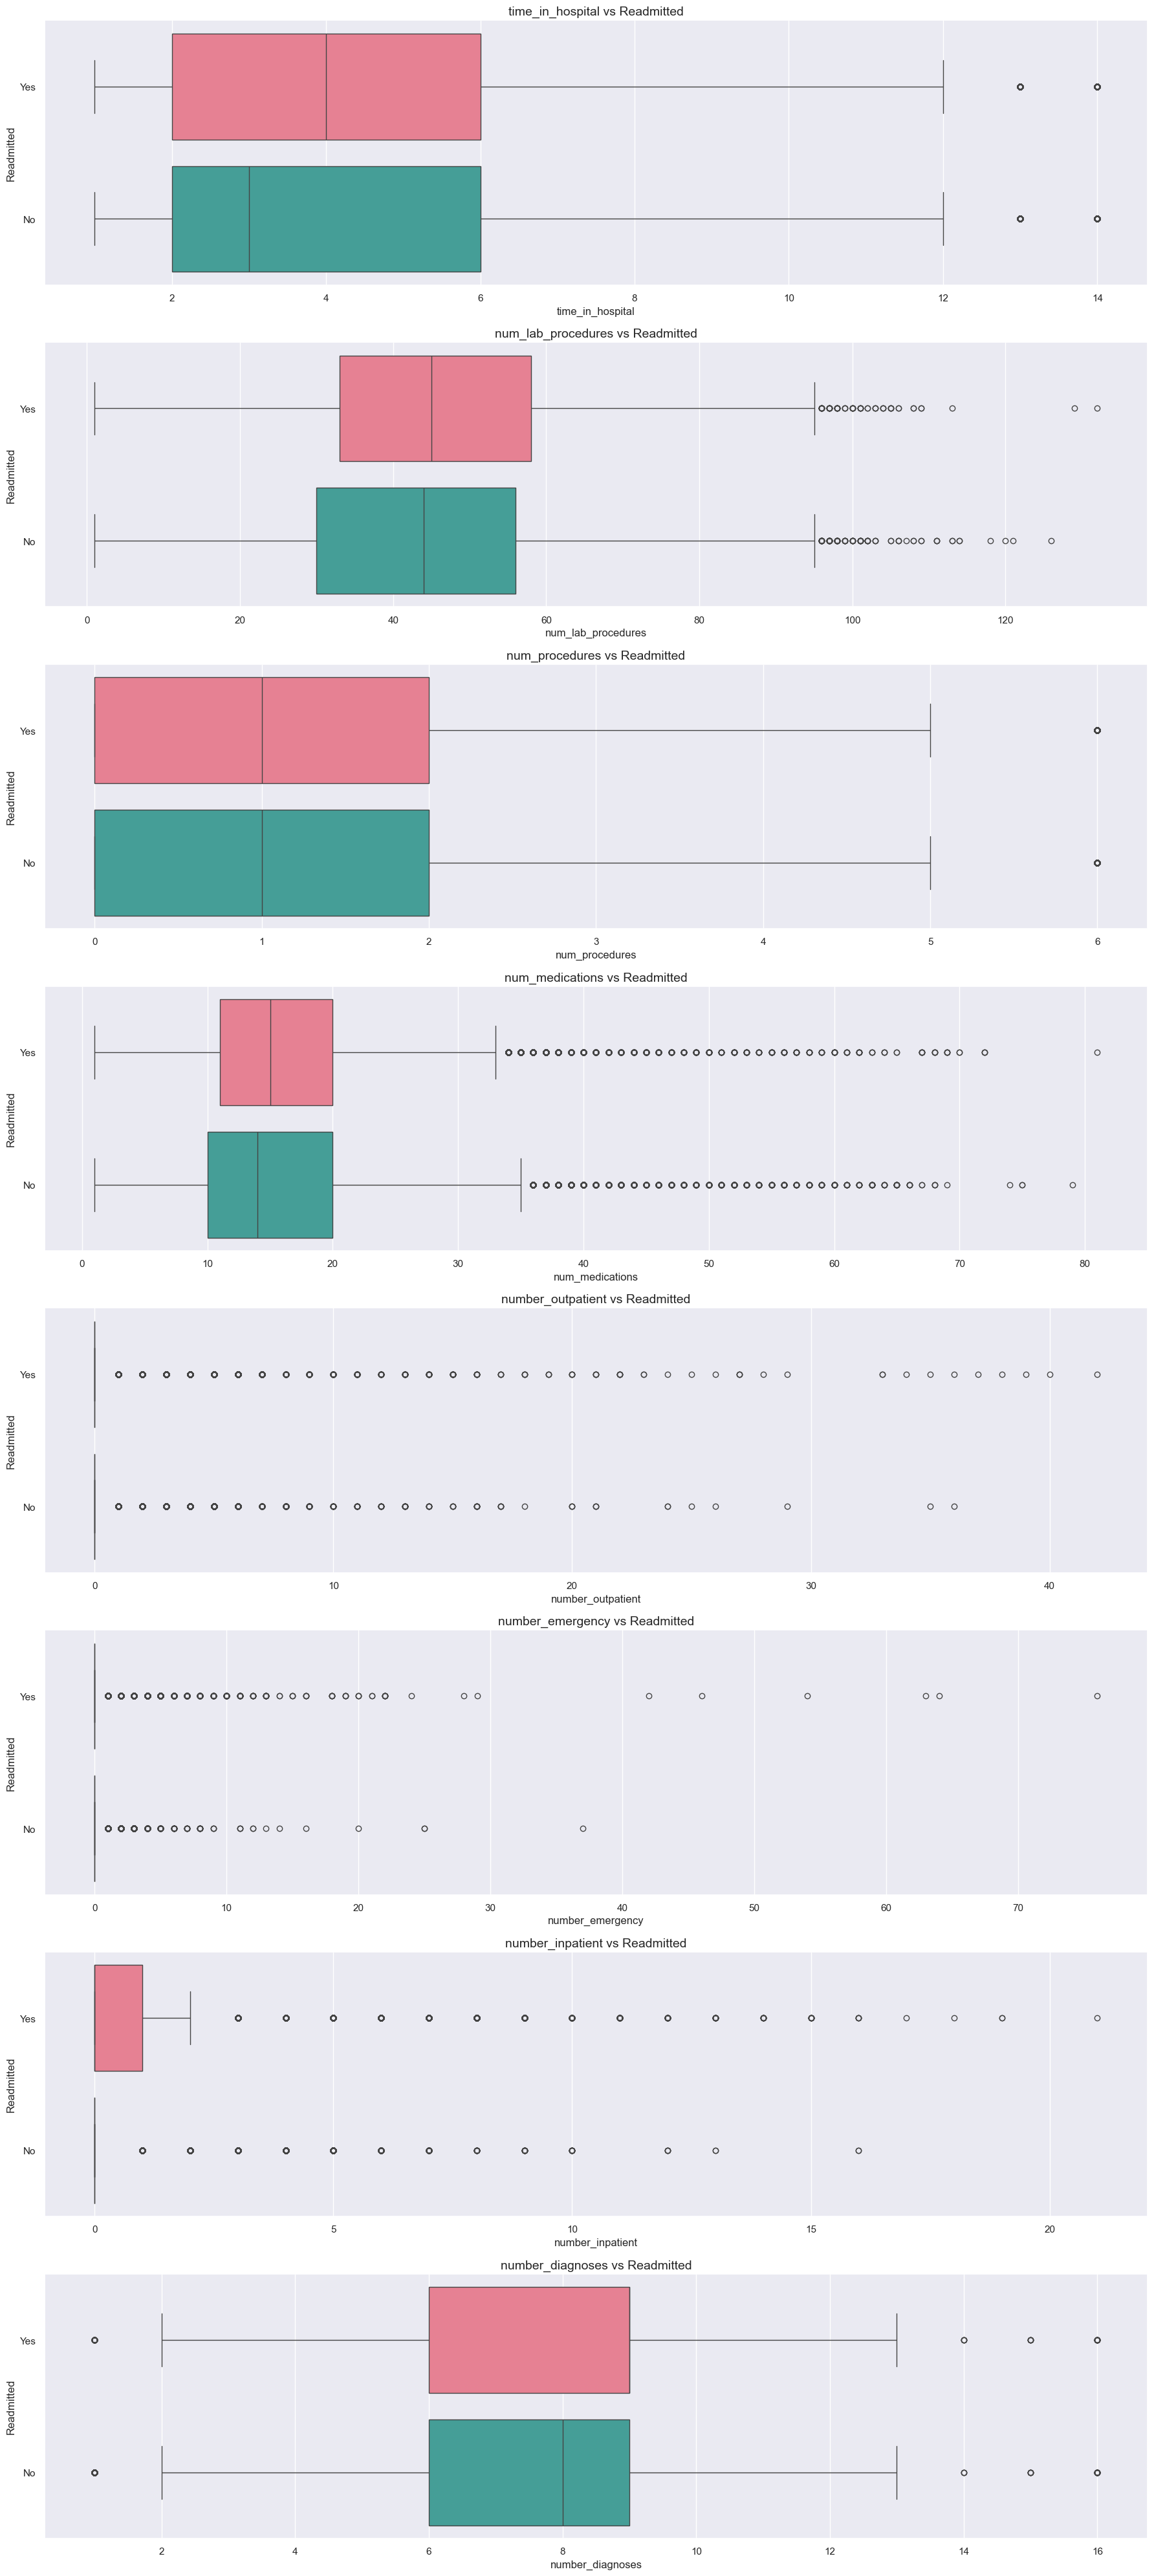

In [12]:
numerical_cols = dbt_dfplot.select_dtypes(include='int64').columns.tolist()

f, axes = plt.subplots(len(numerical_cols), 1, figsize=(18, len(numerical_cols)*5))

for count, var in enumerate(numerical_cols):
    sb.boxplot(x=var, y='readmitted', data=dbt_dfplot, 
               palette="husl", ax=axes[count])
    axes[count].set_title(f'{var} vs Readmitted', fontsize=14)
    axes[count].set_xlabel(var)
    axes[count].set_ylabel('Readmitted')
    

plt.tight_layout()
plt.show()

#### Categorical (Bi-Variate)
- Readmitted against the shortlisted categoricals (i.e. dominance ratio <90%)

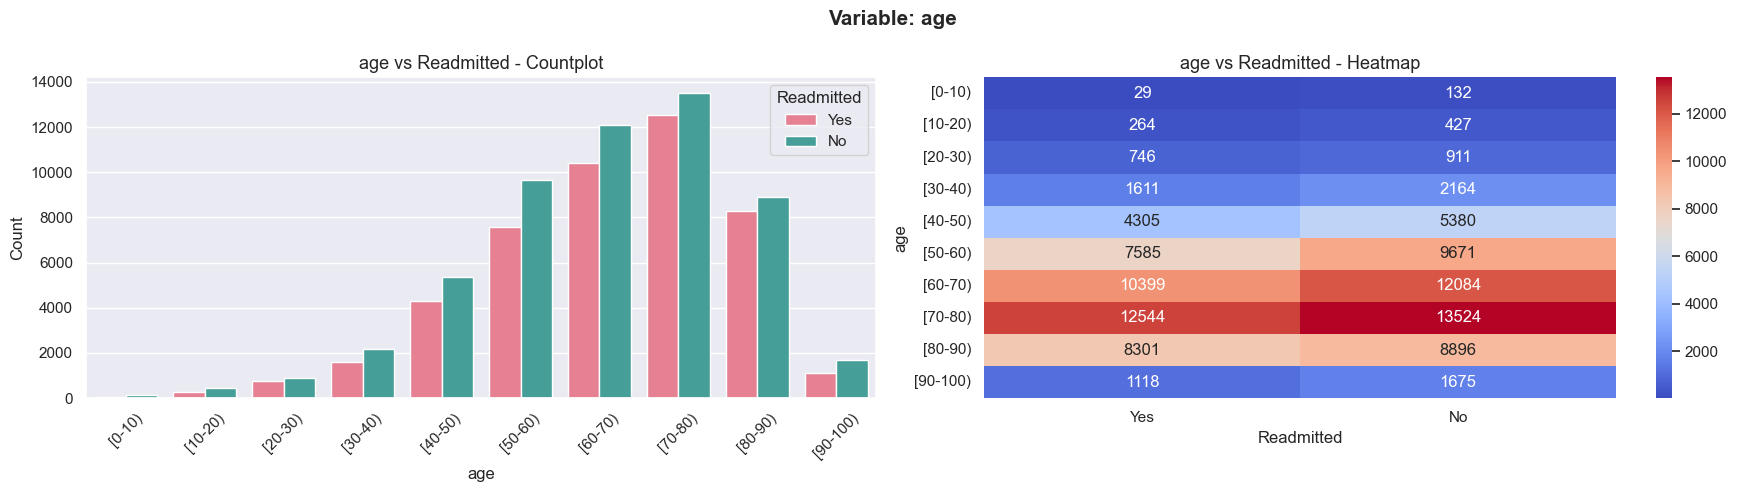

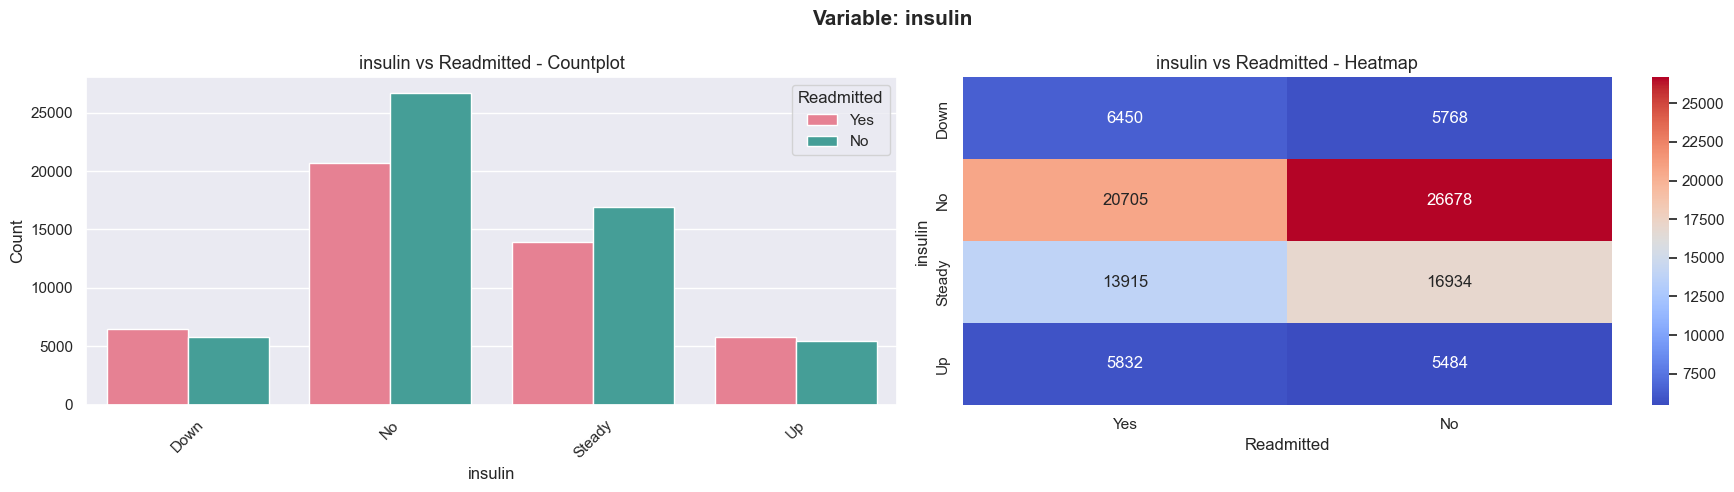

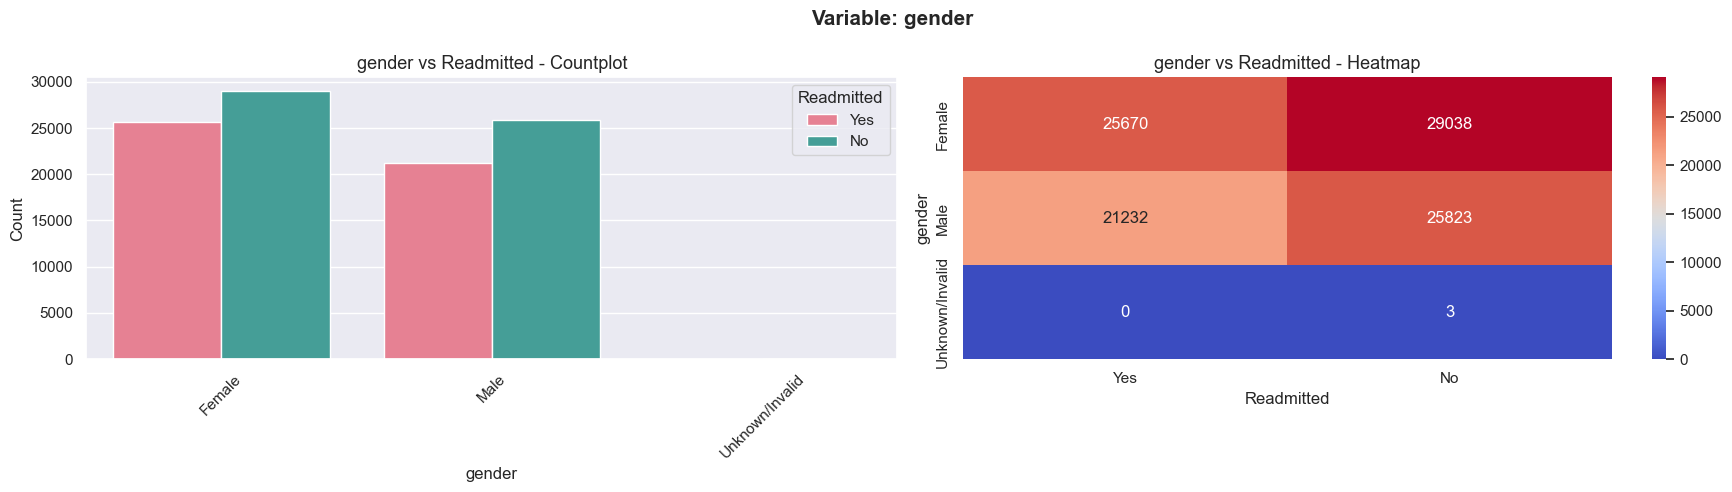

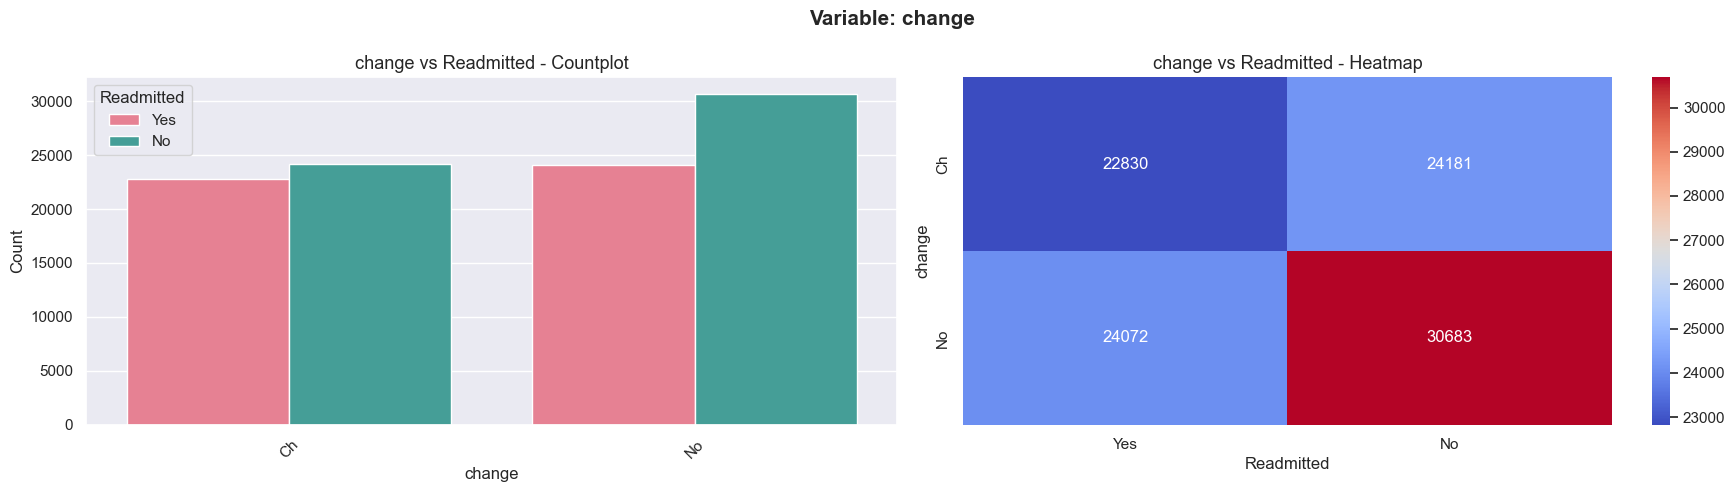

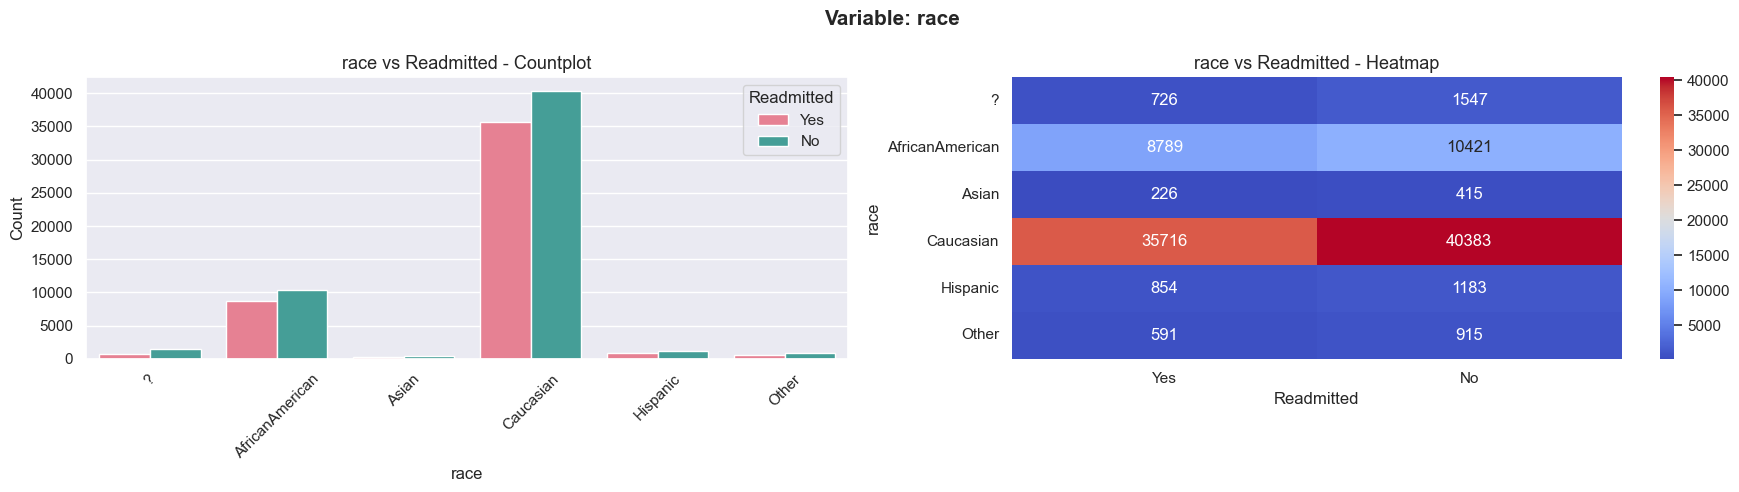

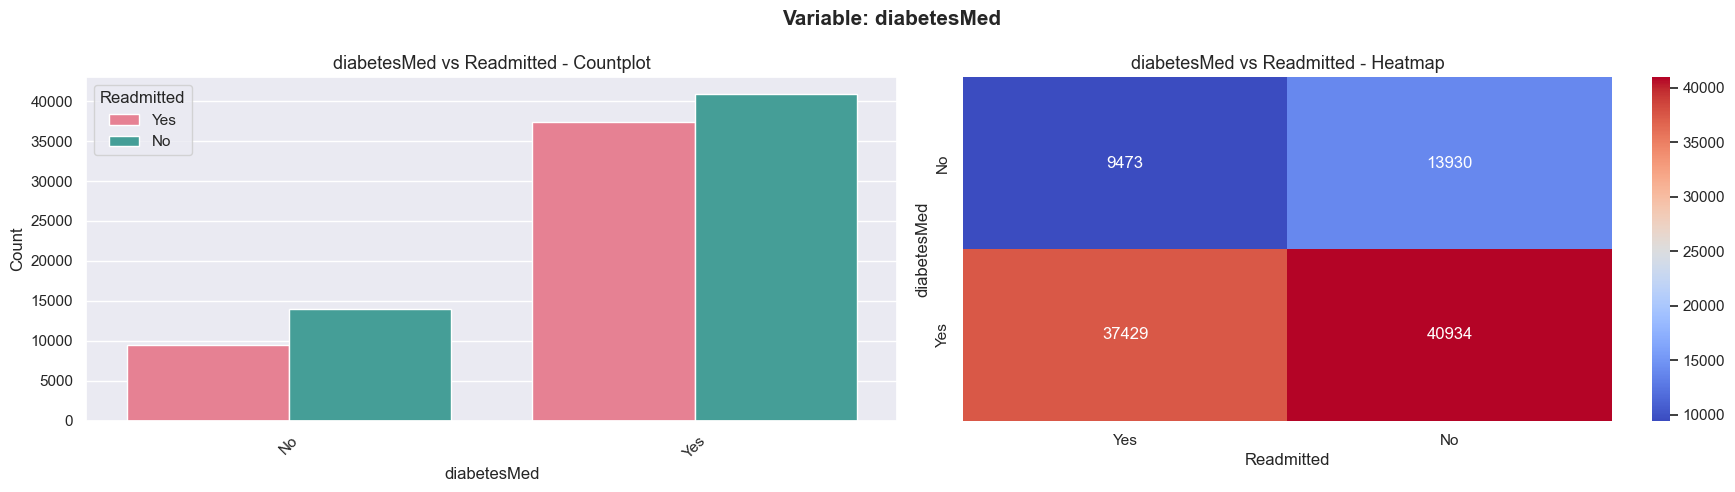

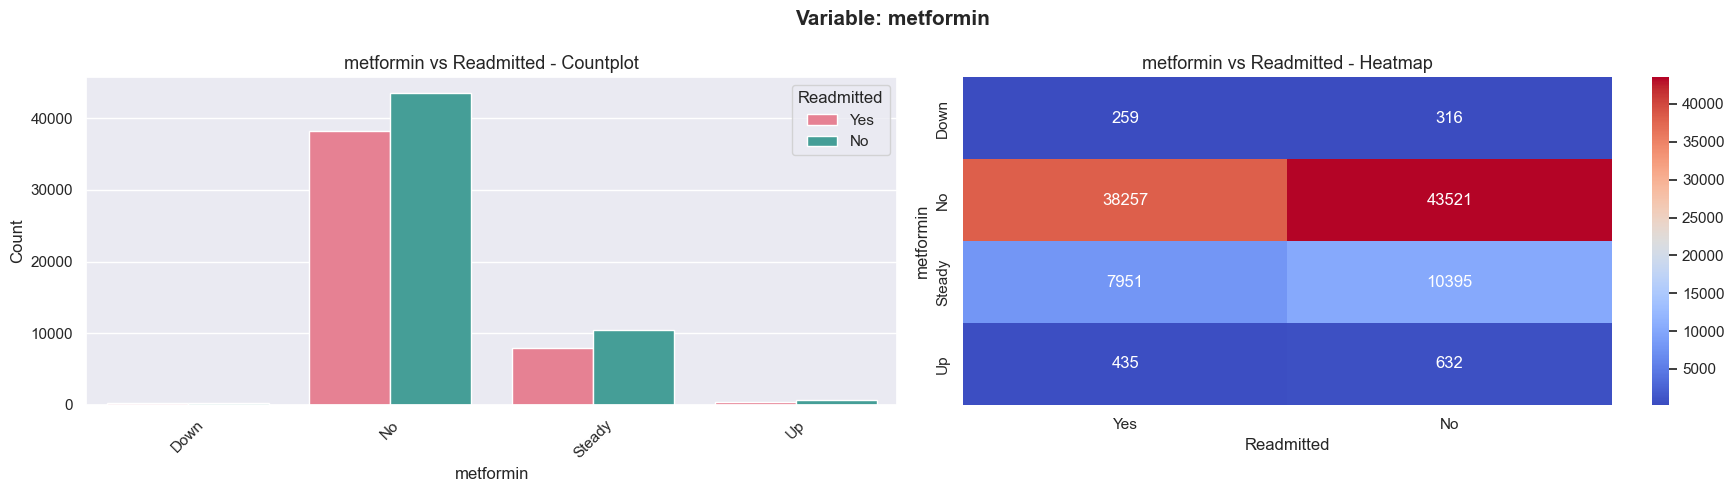

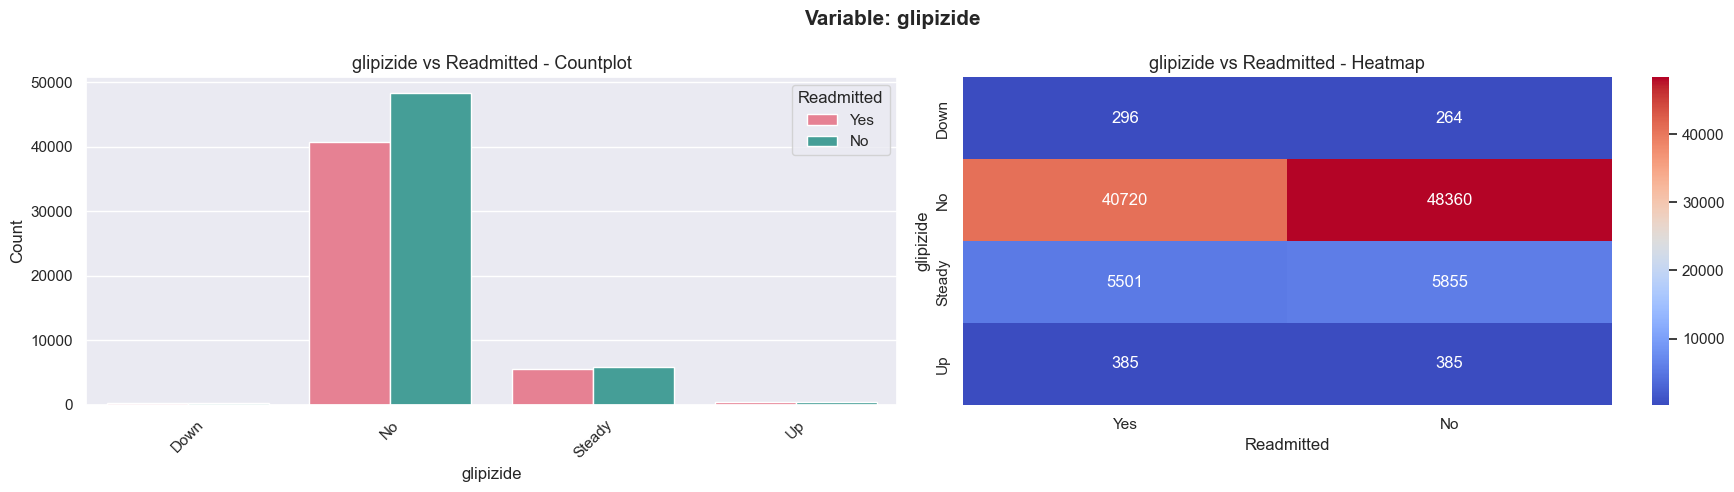

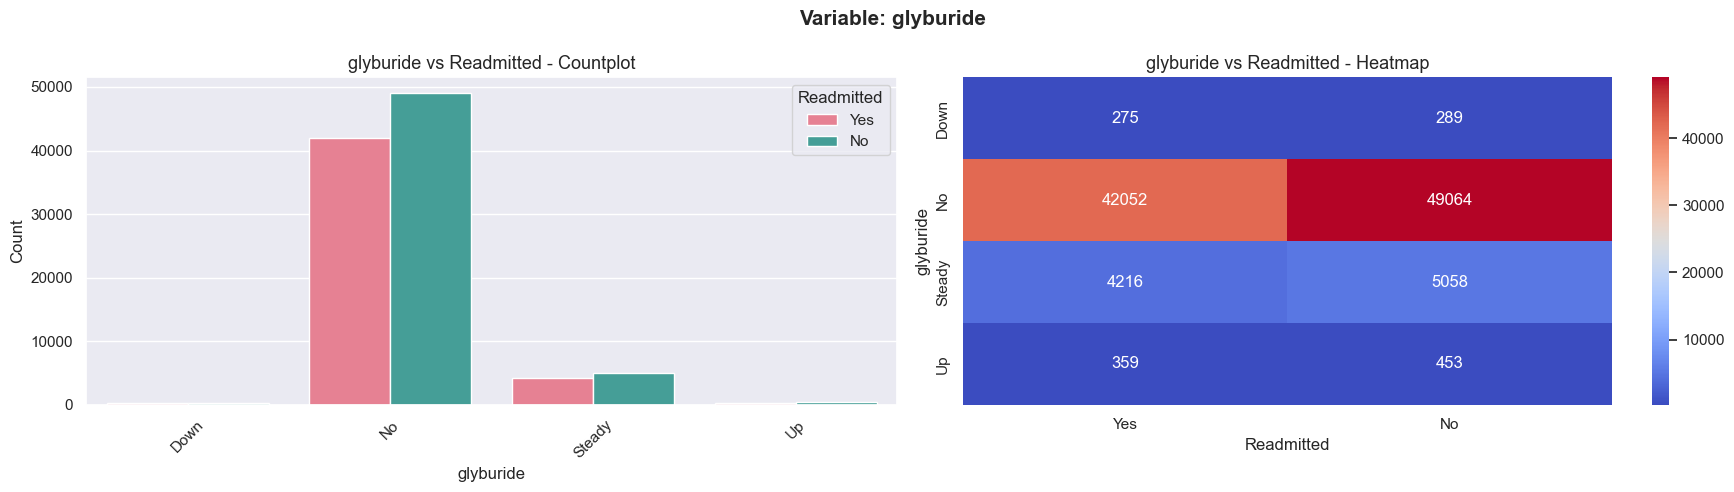

In [13]:
categorical_cols = ['age', 'insulin', 'gender', 'change', 
                    'race', 'diabetesMed', 'metformin', 'glipizide','glyburide']

for var in categorical_cols:
    f, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    # Countplot with hue
    sb.countplot(x=var, hue='readmitted', data=dbt_dfplot, 
                 palette='husl', ax=axes[0])
    axes[0].set_title(f'{var} vs Readmitted - Countplot', fontsize=13)
    axes[0].set_xlabel(var)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title='Readmitted')

    # Heatmap of crosstab
    ct = pd.crosstab(dbt_dfplot[var], dbt_dfplot['readmitted'])
    sb.heatmap(ct, annot=True, fmt='.0f', cmap='coolwarm', 
               annot_kws={"size": 12}, ax=axes[1])
    axes[1].set_title(f'{var} vs Readmitted - Heatmap', fontsize=13)
    axes[1].set_xlabel('Readmitted')
    axes[1].set_ylabel(var)

    plt.suptitle(f'Variable: {var}', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Step 3: *Machine Learning using Binary Decision Classification Tree and results*

#### Carrying out the Binary Decision Tree on our whole data 

# Please uncomment this after the the Binary Decision Tree has been carried out on the whole data set
dbt_df_data = dbt_dfplot.copy()
dbt_df_data.shape
dbt_df_data

##### Please change kernel below cell from markdown to code when filtering the data using gender (Male or Female) of the patient 
> First check for Male and then for Female

In [14]:
dbt_df_data = dbt_dfplot[(dbt_dfplot['gender'] == 'Male')] # filtering for male
# dbt_df_data = dbt_dfplot[(dbt_dfplot['gender'] == 'Female')] # filtering for female

dbt_df_data

,race,gender,age,weight,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
3,Caucasian,Male,[30-40),?,2,44,1,16,0,0,...,No,Up,No,No,No,No,No,Ch,Yes,No
4,Caucasian,Male,[40-50),?,1,51,0,8,0,0,...,No,Steady,No,No,No,No,No,Ch,Yes,No
5,Caucasian,Male,[50-60),?,3,31,6,16,0,0,...,No,Steady,No,No,No,No,No,No,Yes,Yes
6,Caucasian,Male,[60-70),?,4,70,1,21,0,0,...,No,Steady,No,No,No,No,No,Ch,Yes,No
7,Caucasian,Male,[70-80),?,5,73,0,12,0,0,...,No,No,No,No,No,No,No,No,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101753,Other,Male,[40-50),?,13,51,2,13,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,No
101759,Caucasian,Male,[80-90),?,1,1,0,15,3,0,...,No,Up,No,No,No,No,No,Ch,Yes,No
101761,AfricanAmerican,Male,[70-80),?,3,51,0,16,0,0,...,No,Down,No,No,No,No,No,Ch,Yes,Yes
101763,Caucasian,Male,[70-80),?,1,53,0,9,1,0,...,No,Down,No,No,No,No,No,Ch,Yes,No


##### Please change kernel below cell from markdown to code when filtering the data using race (Caucasian or African American) of the patient 
> First check for Caucasian and then for African American

dbt_df_data = dbt_dfplot[(dbt_dfplot['race'] == 'Caucasian')] 
# dbt_df_data = dbt_dfplot[(dbt_dfplot['race'] == 'AfricanAmerican')] 

dbt_df_data

In [15]:
# Data Splitting into Train and Test DF.
# Using the random splitting to avoid any time related biasness
mode = 'random'  # change from 'orderly' to 'random'
testsize = 0.2

y = pd.DataFrame(dbt_df_data['readmitted'])
X = dbt_df_data.copy()

if mode == 'orderly':
    Class_train, Class_test, y_train, y_test = train_test_split(X, y, test_size=testsize, shuffle=False)

else:  # random with stratify
    Class_train, Class_test, y_train, y_test = train_test_split(X, y, test_size=testsize, random_state=42, stratify=y)

Class_train.shape

(37644, 38)

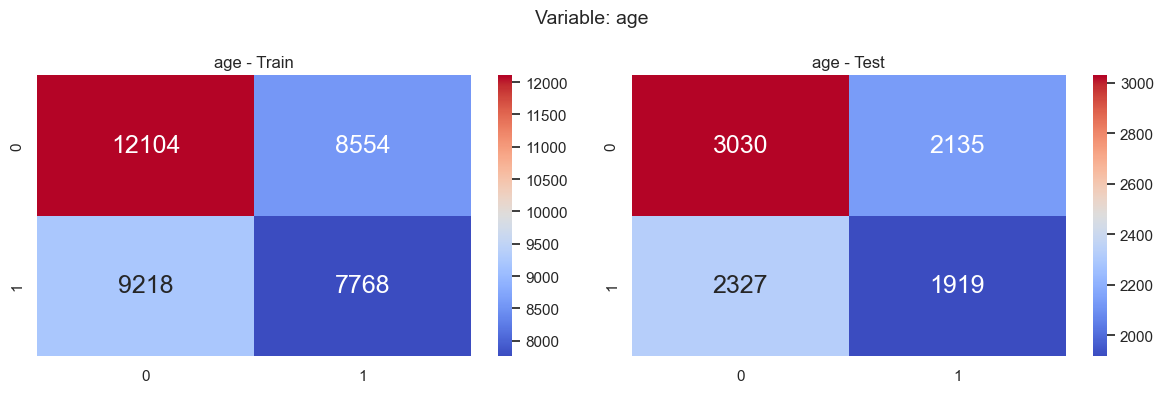

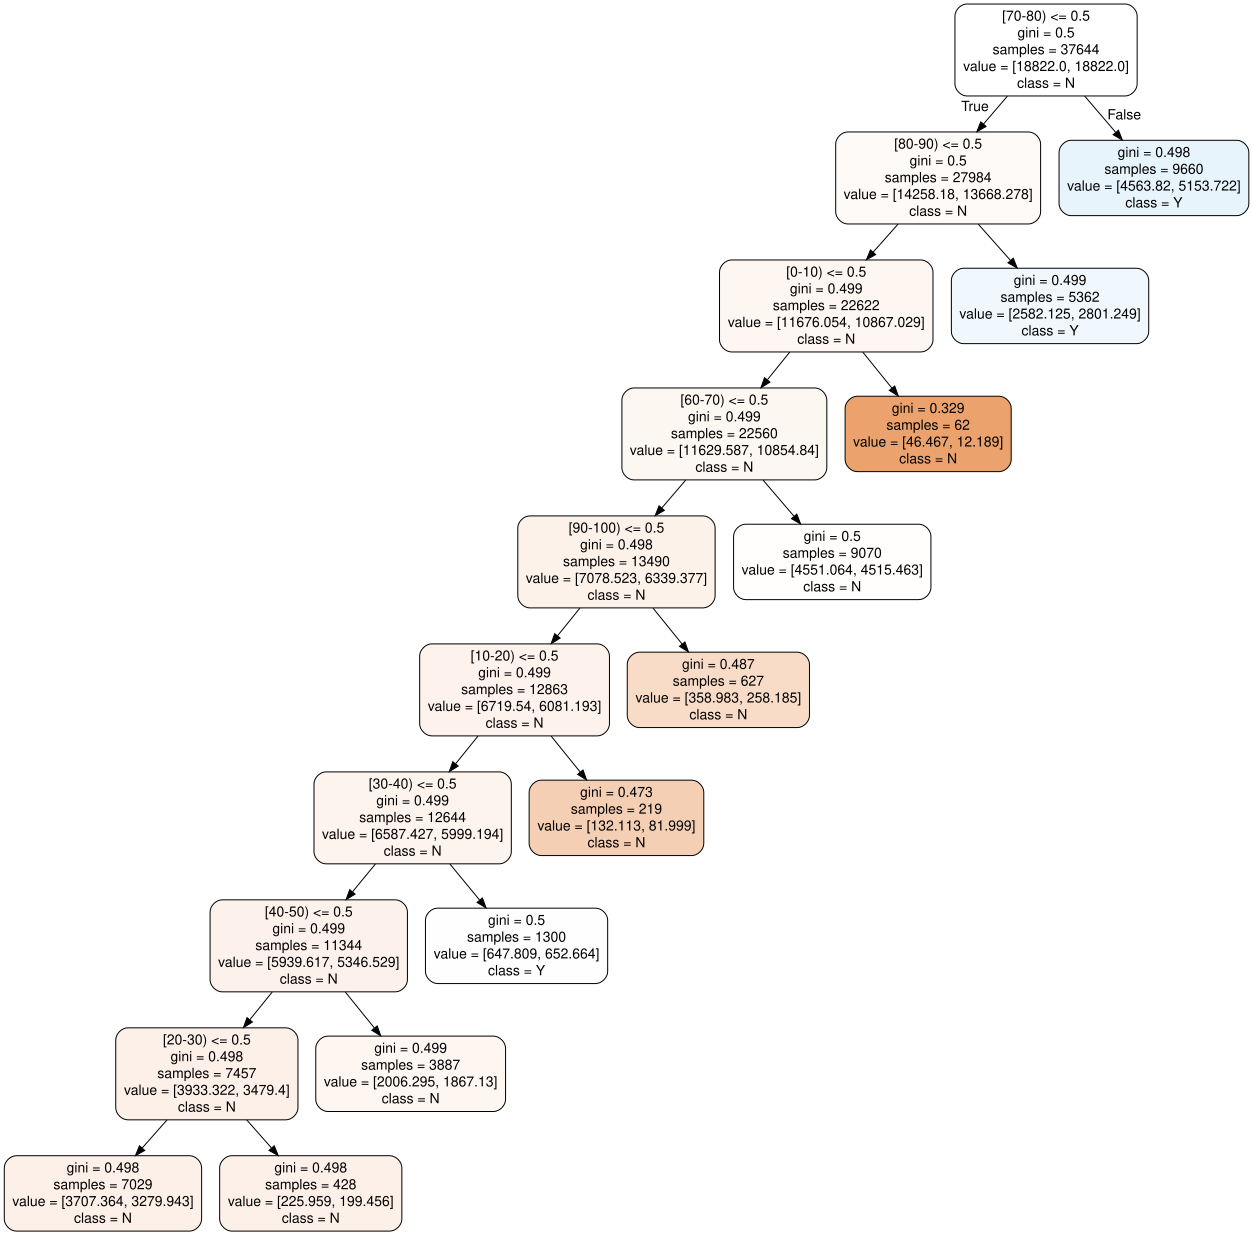

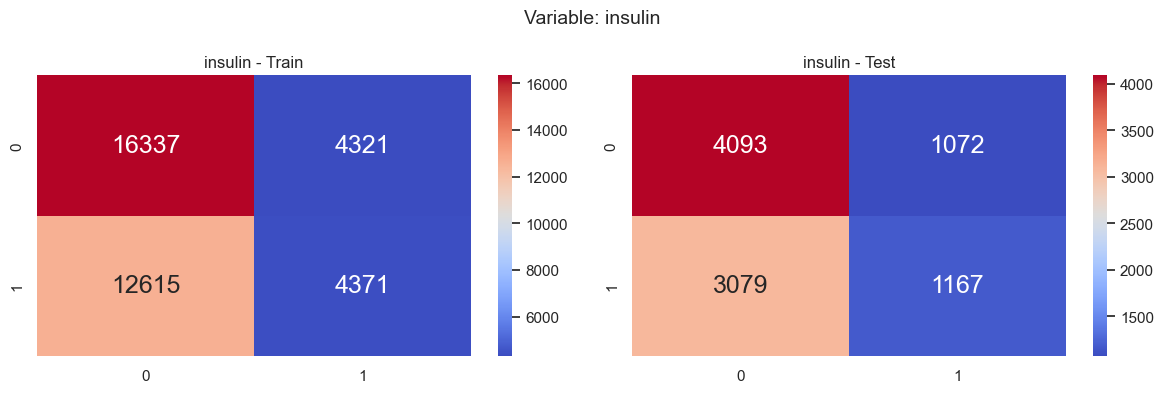

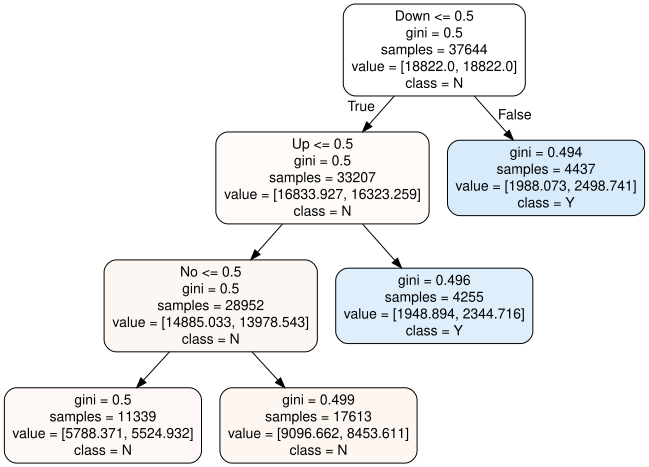

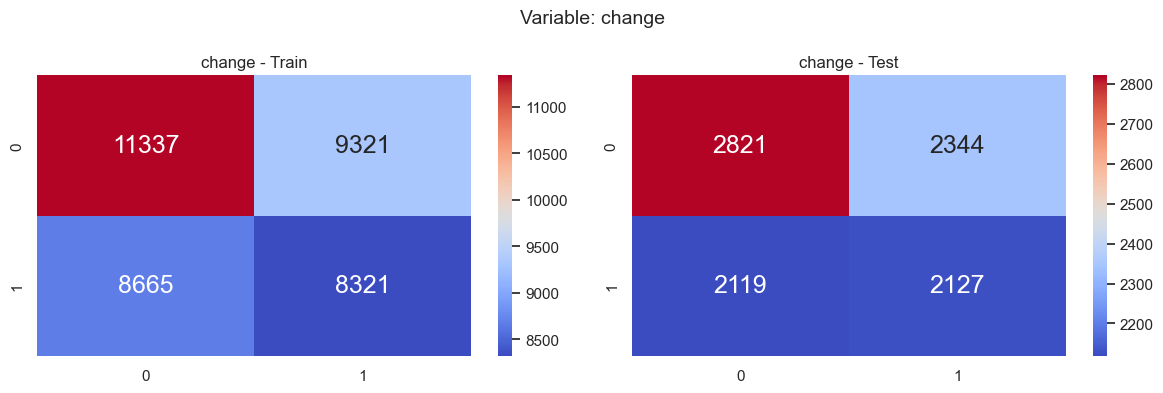

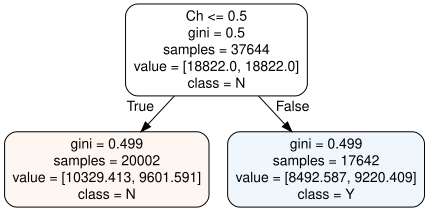

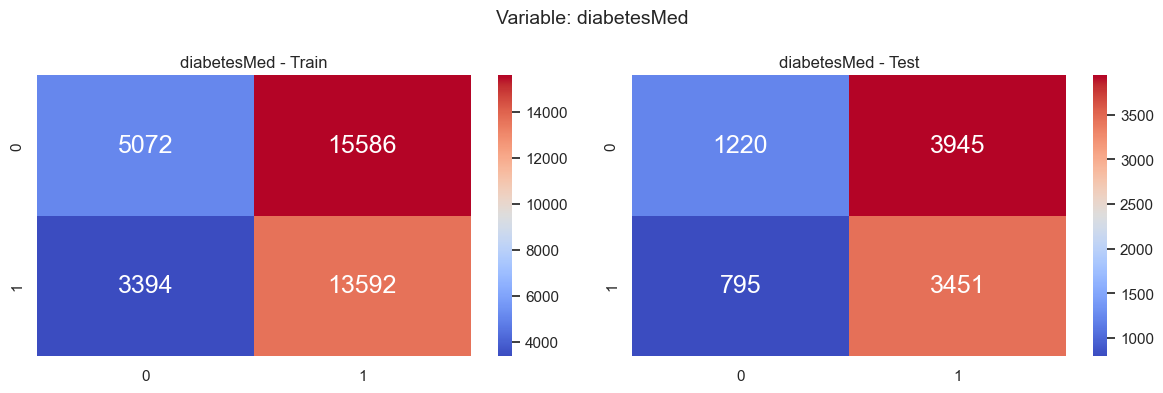

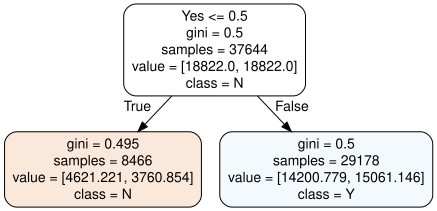

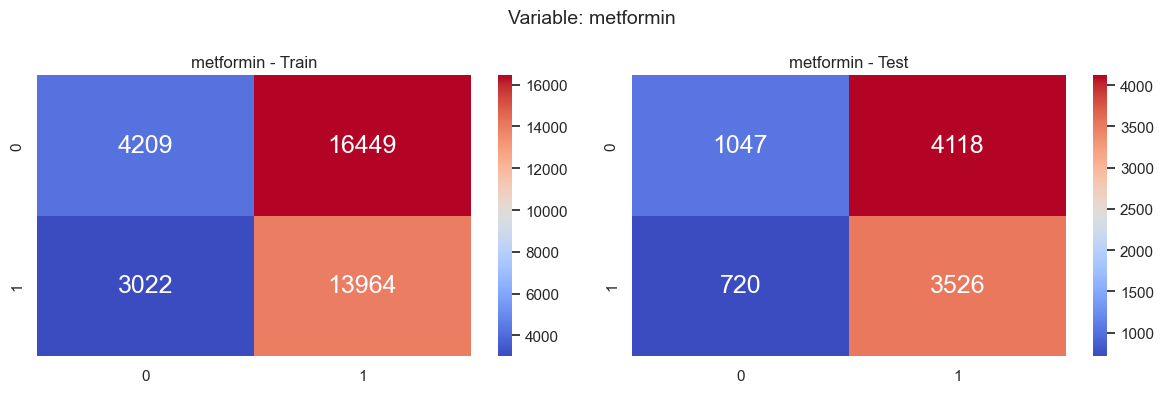

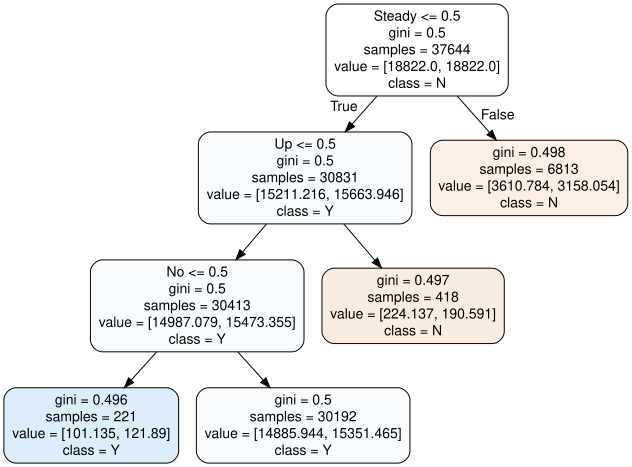

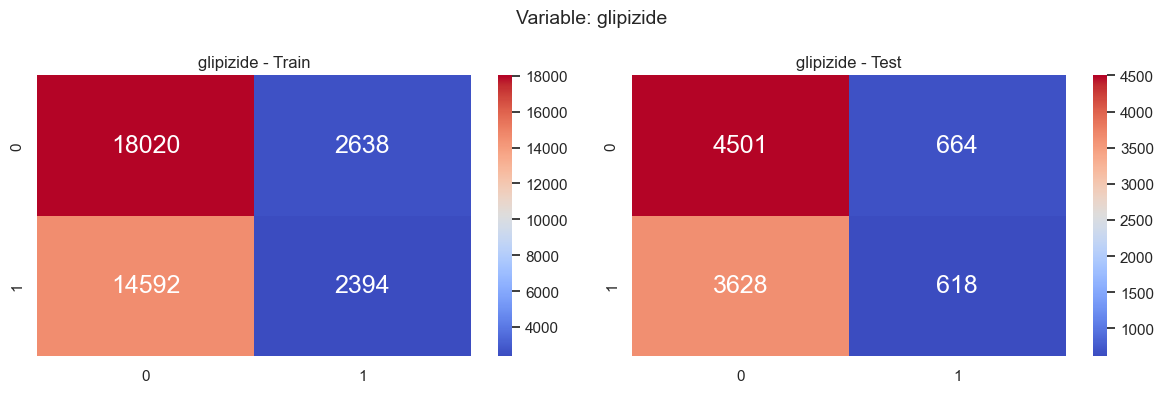

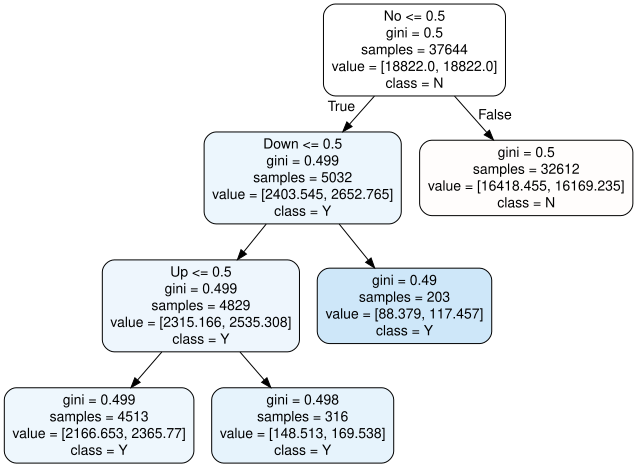

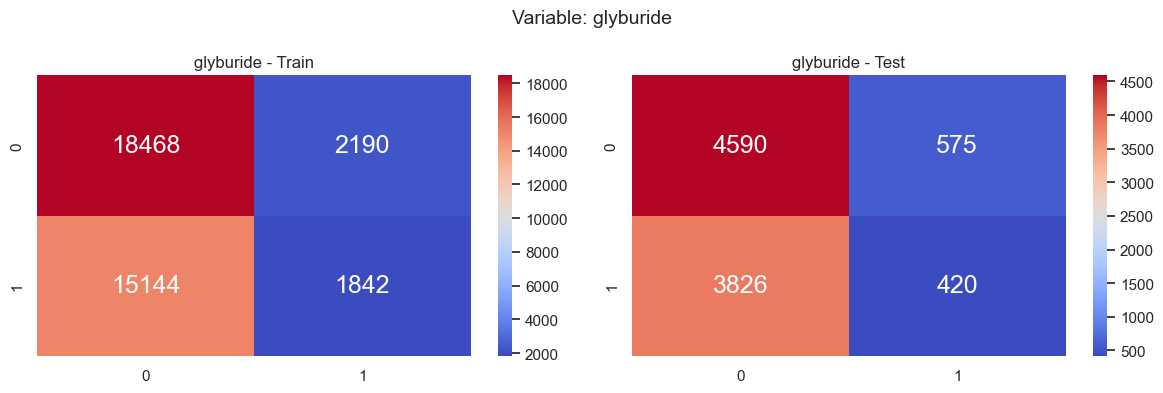

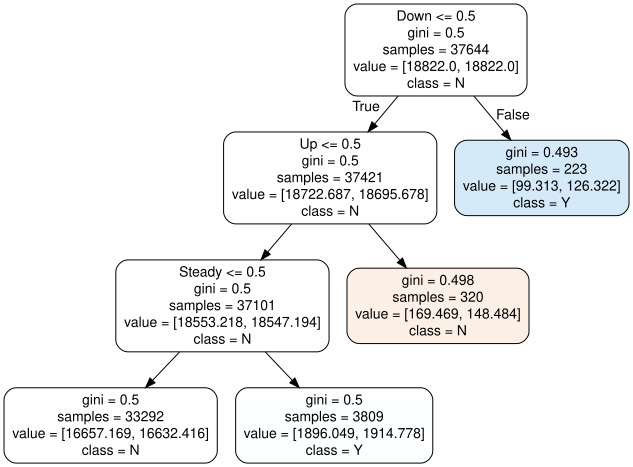

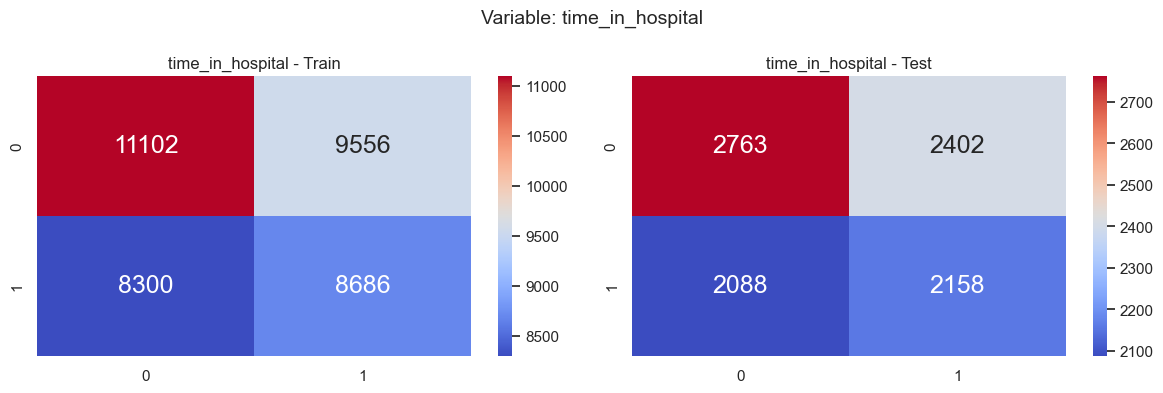

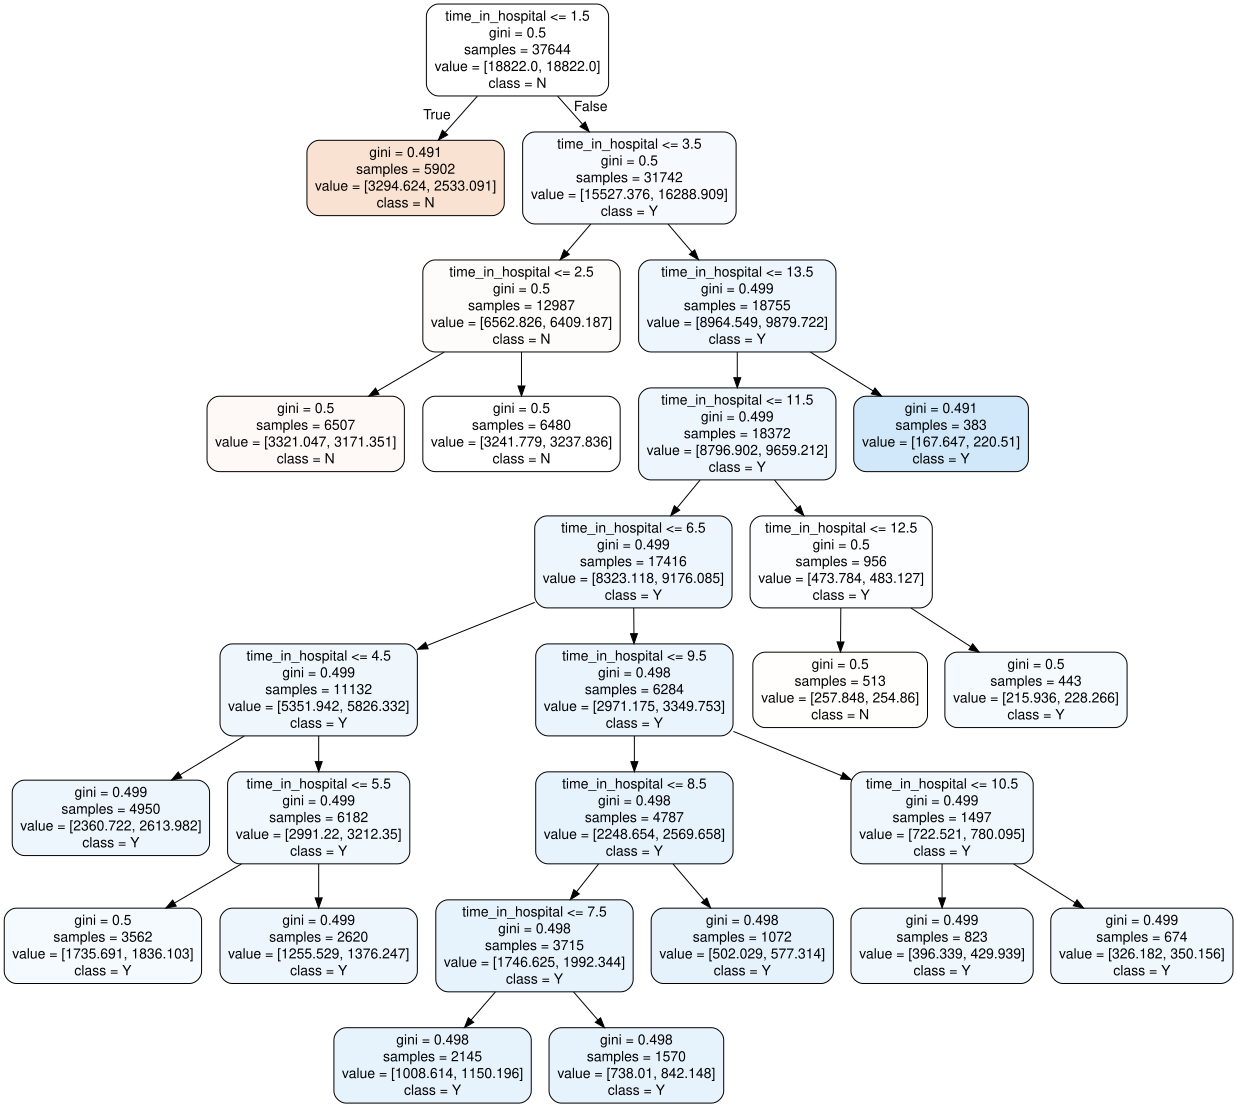

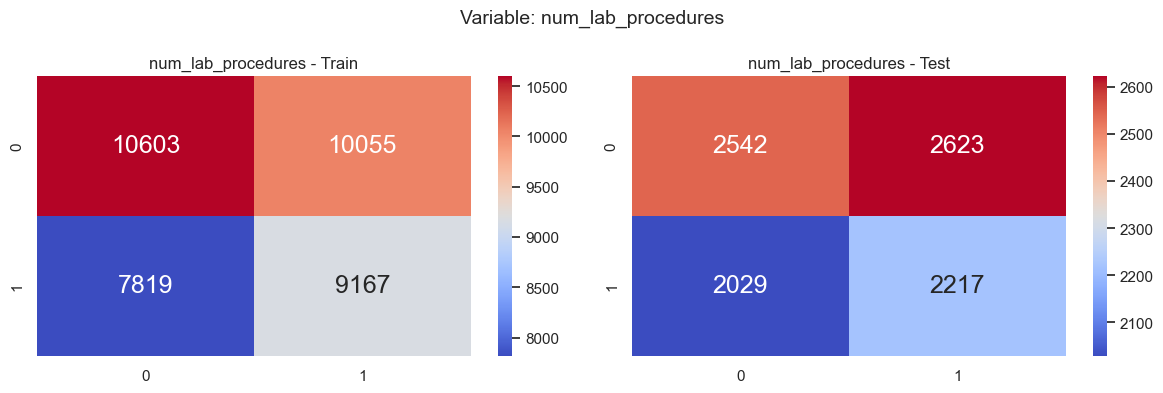

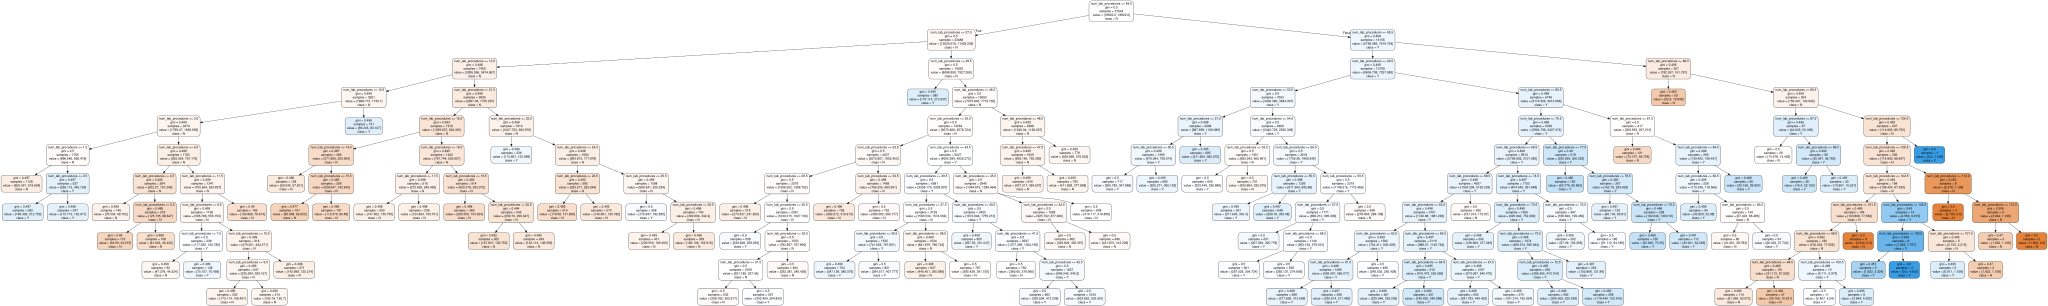

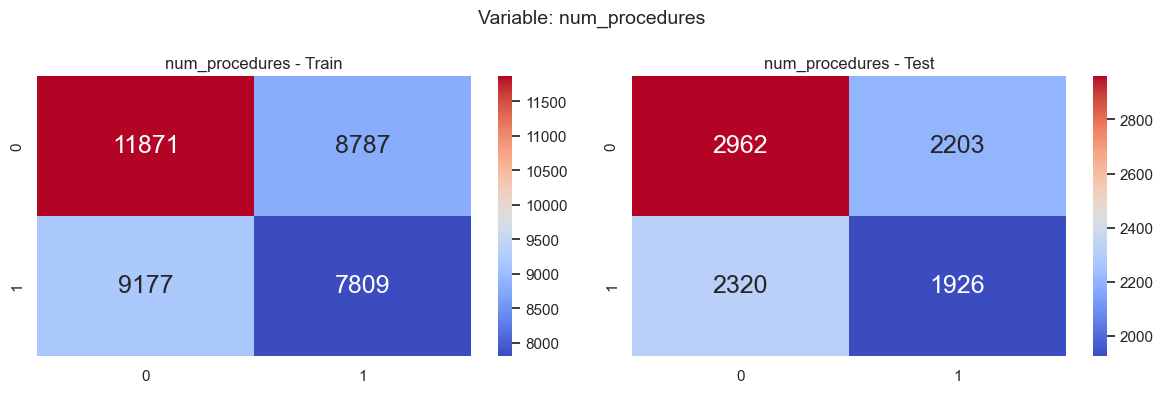

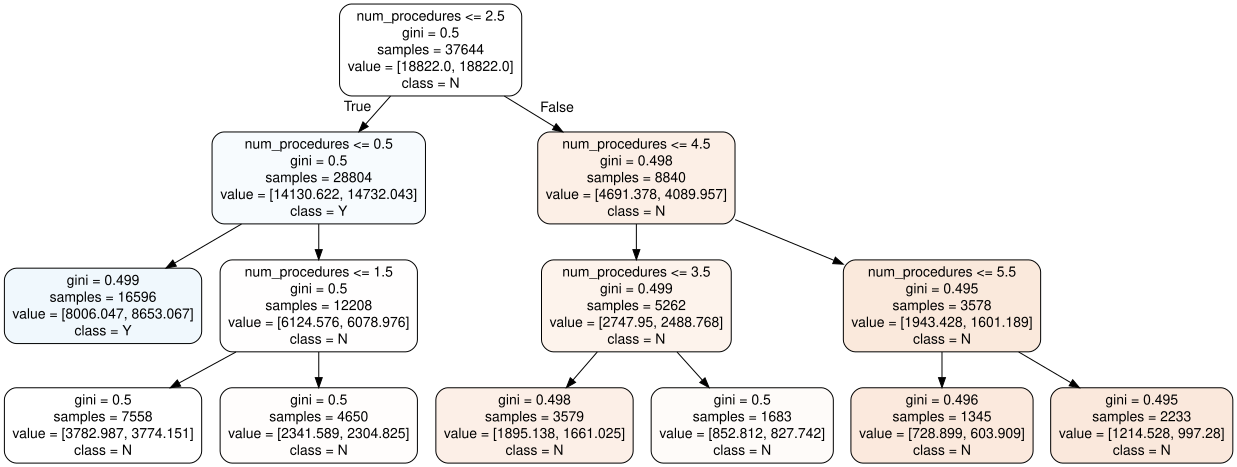

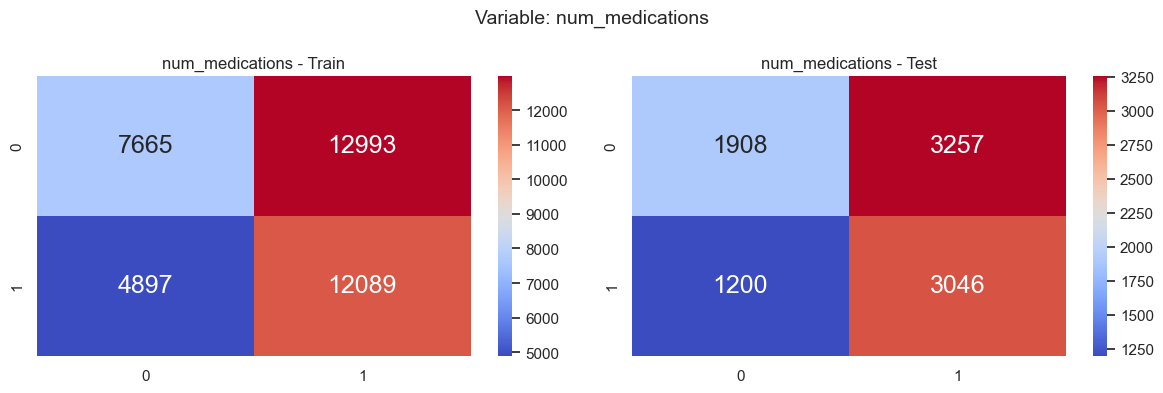

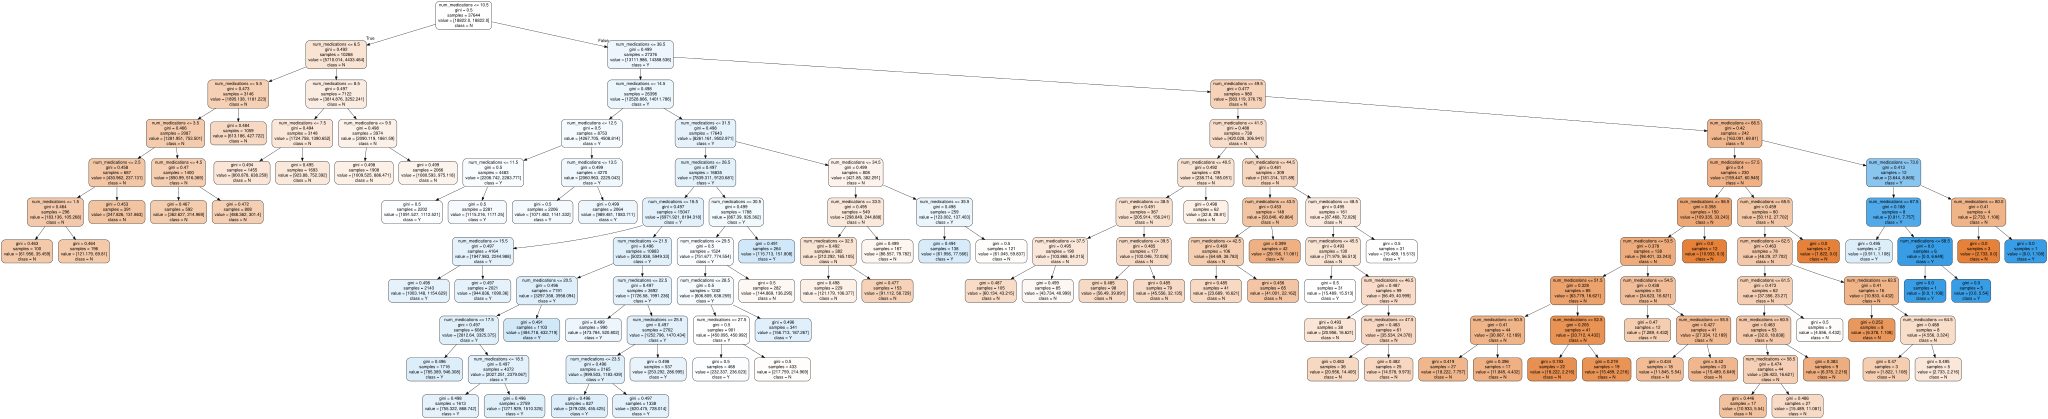

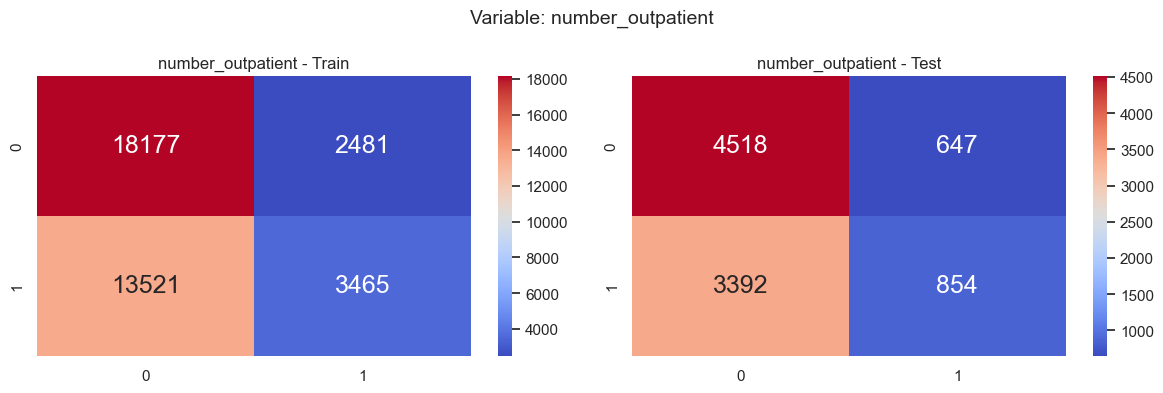

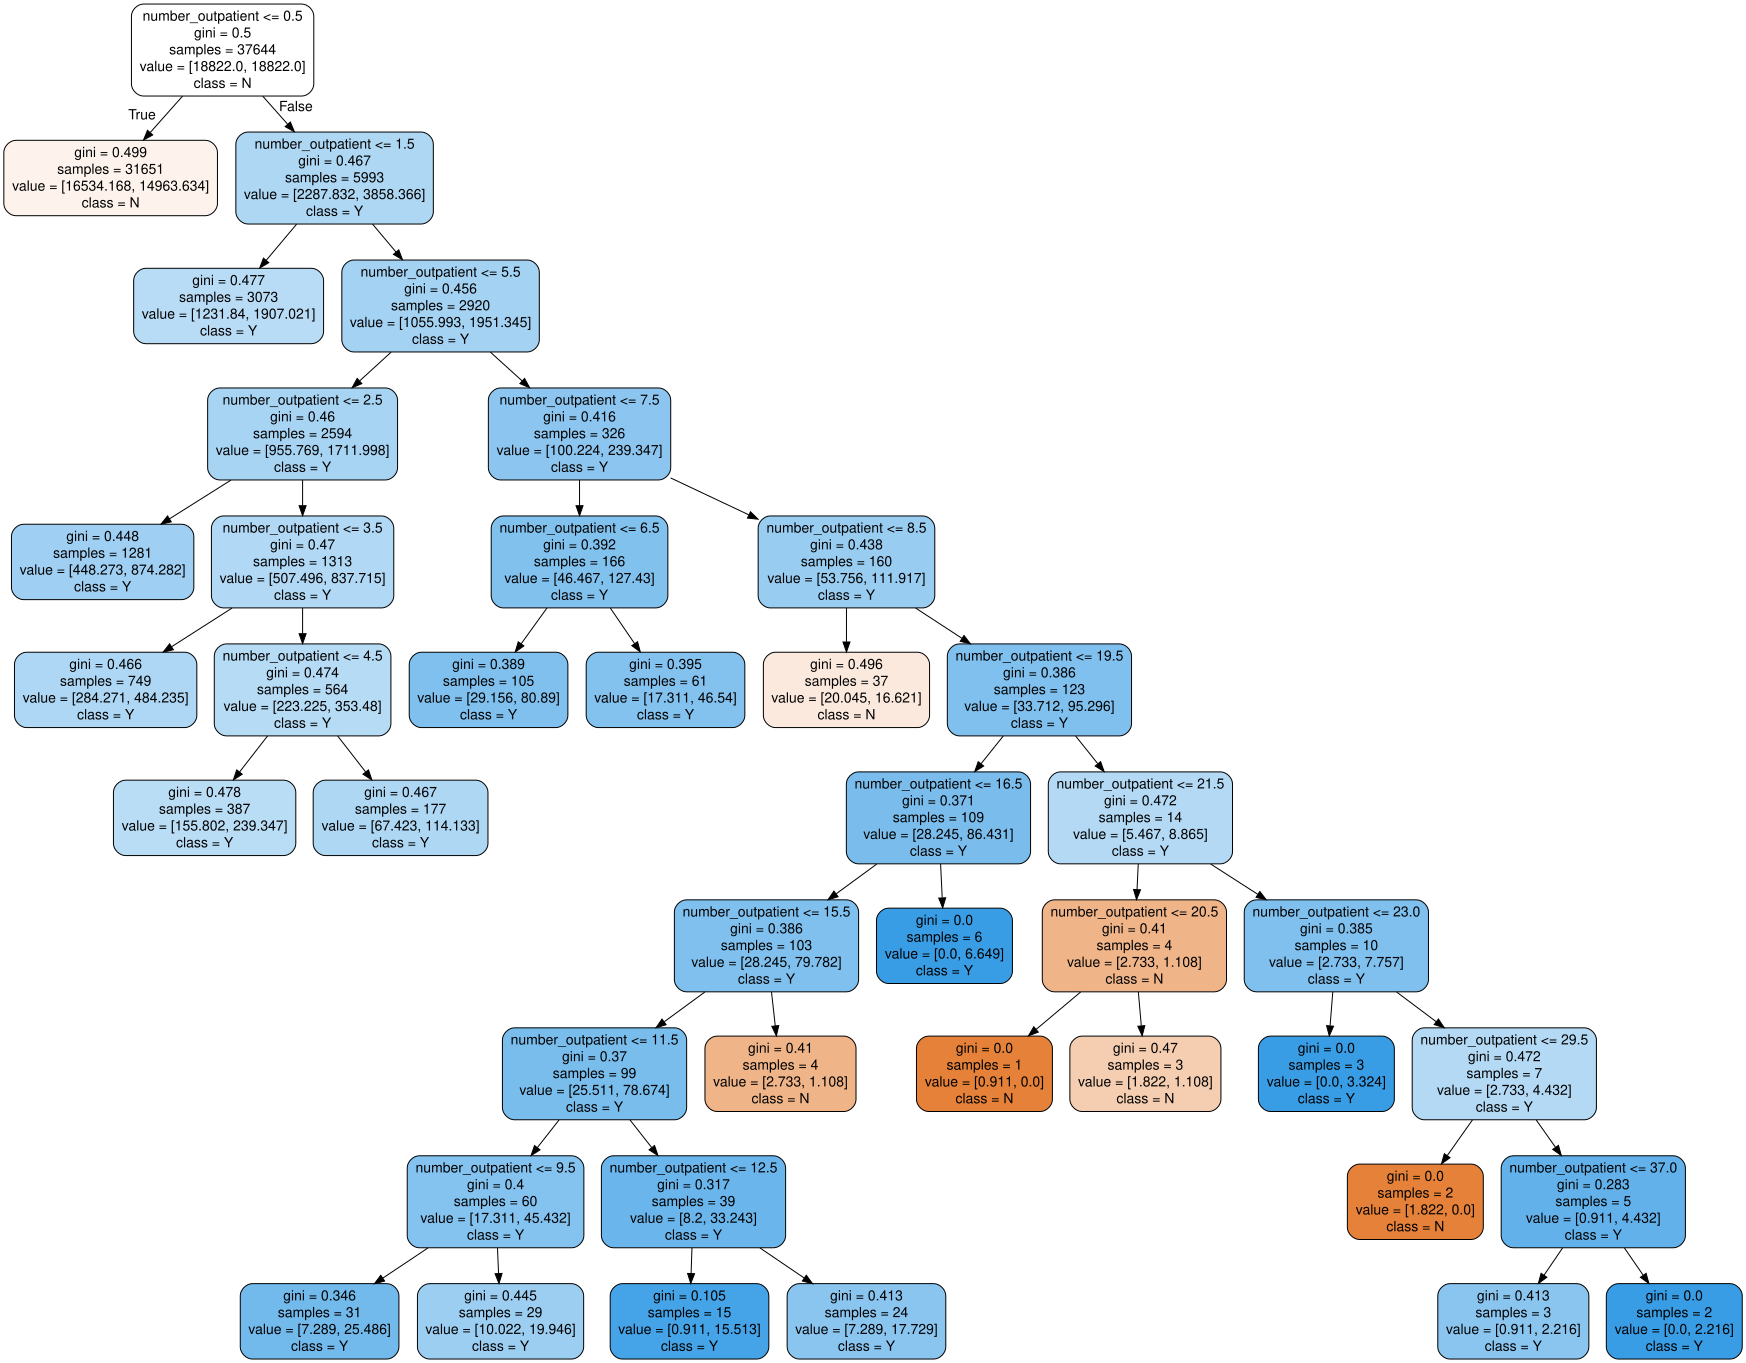

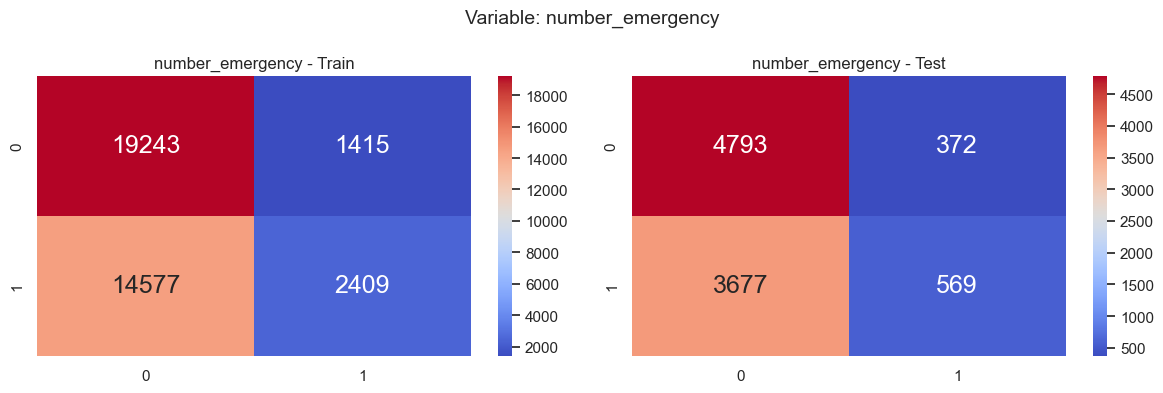

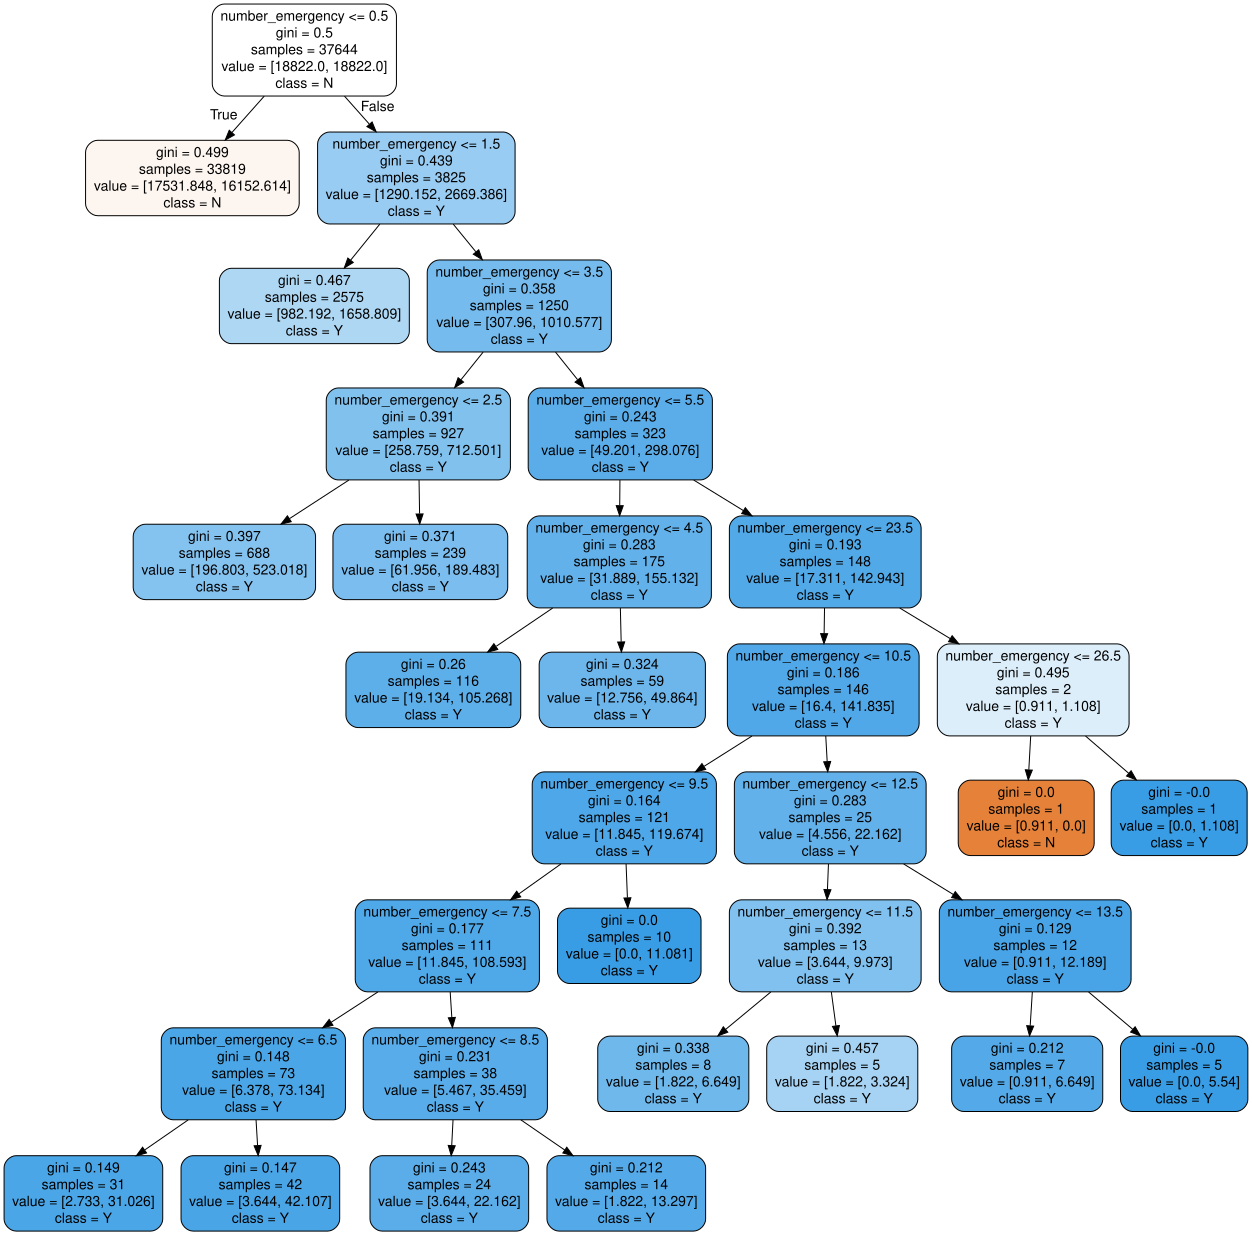

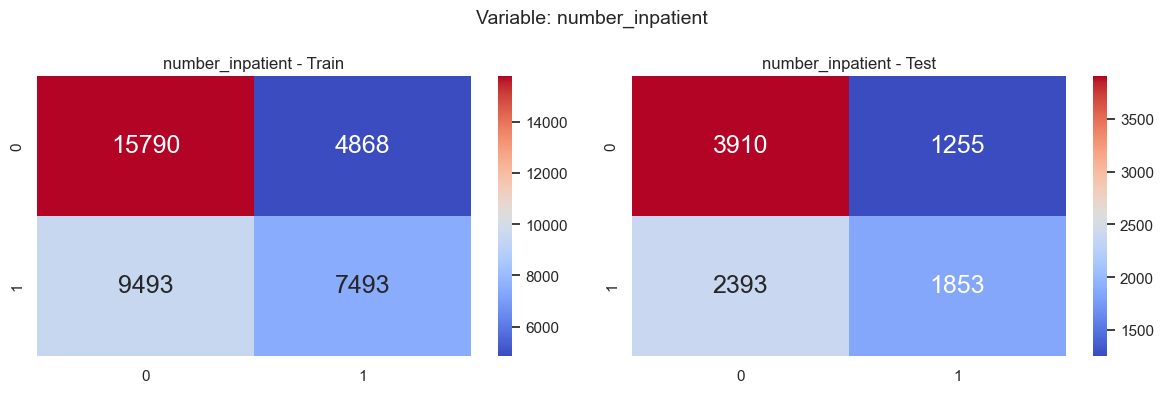

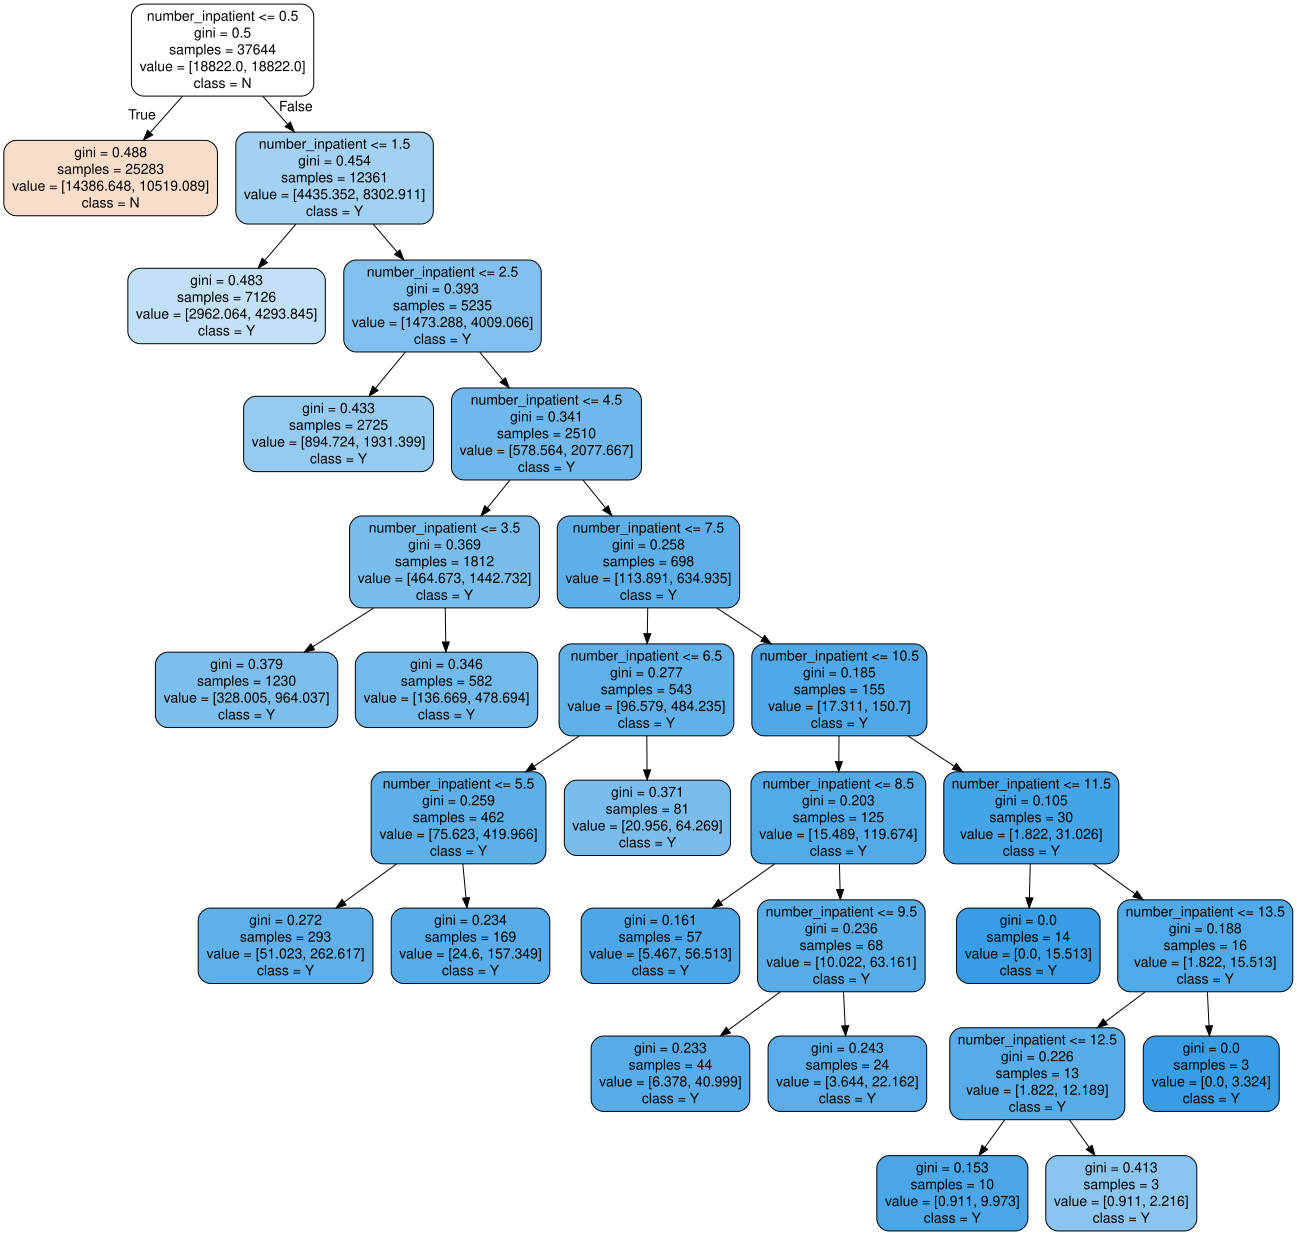

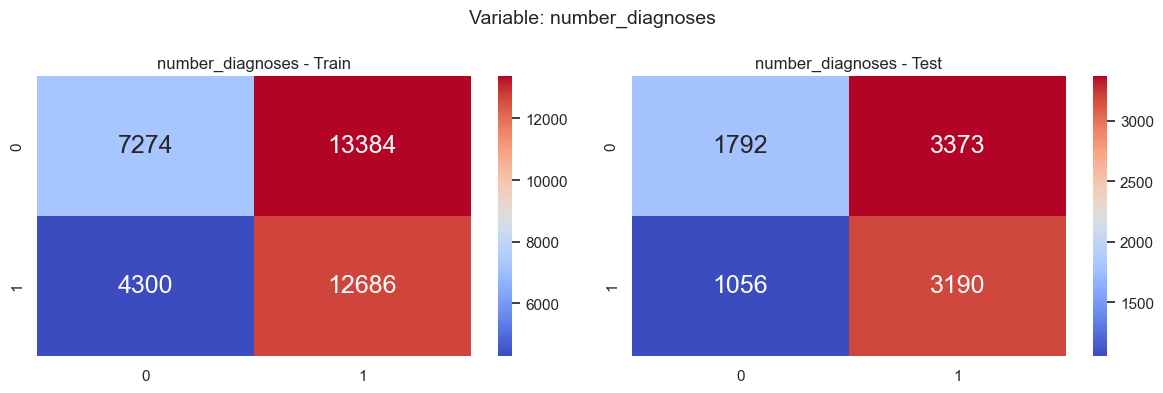

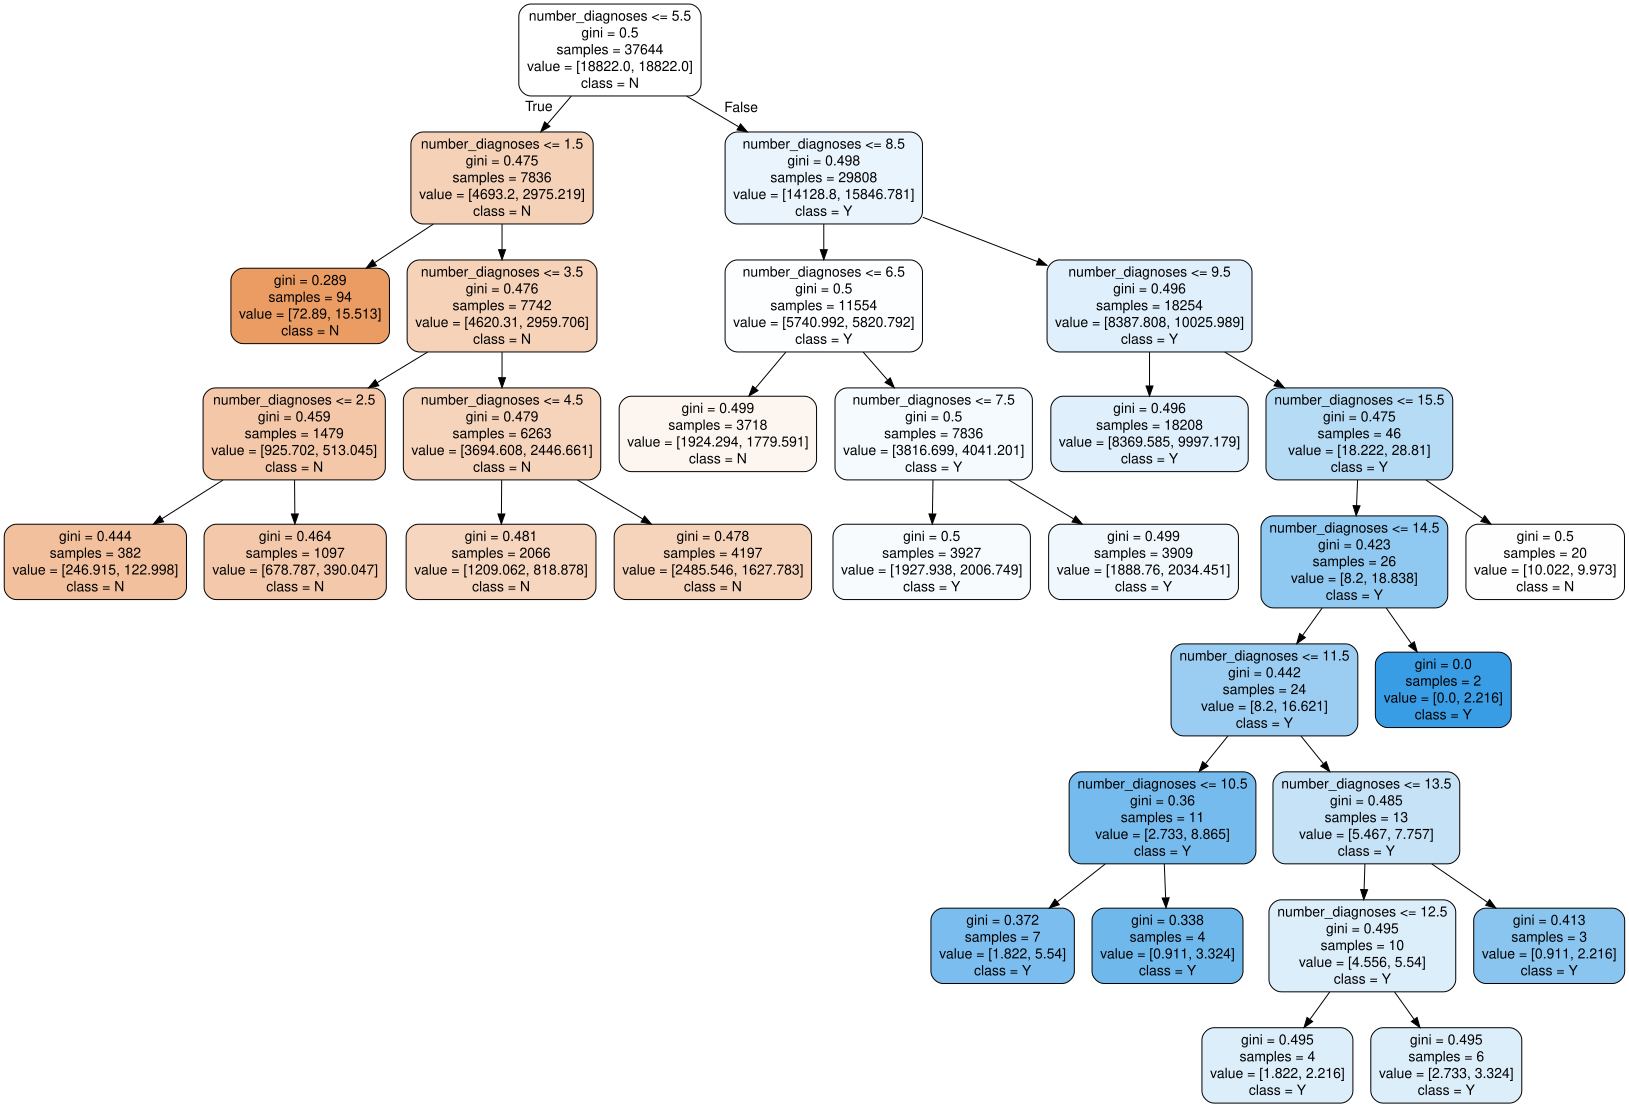

In [19]:
Cat1 = ['age', 'insulin', 'change', 'diabetesMed', 'metformin', 'glipizide','glyburide','time_in_hospital', 'num_lab_procedures', 
        'num_procedures', 'num_medications','number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
categorical_vars = ['age', 'insulin', 'change', 
                     'diabetesMed', 'metformin', 'glipizide','glyburide']

numeric_vars     = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
                    'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

maxdepth = 10 
results_store = list()  # stores raw values for Cell B to use

# To analyse the categorical data into dummy/indicator numerical variables 
for S in Cat1:
    if S in categorical_vars:
        x_train = pd.get_dummies(Class_train[S])
        x_test  = pd.get_dummies(Class_test[S])
        x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)
        dtype_label = 'Categorical'
    else:
        x_train = Class_train[[S]]
        x_test  = Class_test[[S]]
        dtype_label = 'Numerical'

    # Fit and predict
    dectree = DecisionTreeClassifier(max_depth=maxdepth, class_weight='balanced')
    dectree.fit(x_train, y_train)
    y_train_pred = dectree.predict(x_train)
    y_test_pred  = dectree.predict(x_test)

    # Accuracy
    class_acc_score_train = dectree.score(x_train, y_train)
    class_acc_score_test  = dectree.score(x_test,  y_test)

    # Heat Map
    f, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].set_title(f'{S} - Train')
    axes[1].set_title(f'{S} - Test')
    sb.heatmap(confusion_matrix(y_train, y_train_pred),
               annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axes[0], cmap="coolwarm")
    sb.heatmap(confusion_matrix(y_test, y_test_pred),
               annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axes[1], cmap="coolwarm")
    plt.suptitle(f'Variable: {S}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Decision Tree
    treedot = export_graphviz(dectree,
                              feature_names=x_train.columns,
                              out_file=None,
                              filled=True,
                              rounded=True,
                              special_characters=False, # change this to false for the A1Cresult
                              class_names=['N','Y'])
    display(graphviz.Source(treedot))

    
    [tn_train, fp_train, fn_train, tp_train] = confusion_matrix(y_train, y_train_pred).ravel()
    [tn_test,  fp_test,  fn_test,  tp_test]  = confusion_matrix(y_test,  y_test_pred).ravel()

    results_store.append({
        'S': S, 'dtype_label': dtype_label,
        'acc_train': class_acc_score_train, 'acc_test': class_acc_score_test,
        'tn_train': tn_train, 'fp_train': fp_train, 'fn_train': fn_train, 'tp_train': tp_train,
        'tn_test':  tn_test,  'fp_test':  fp_test,  'fn_test':  fn_test,  'tp_test':  tp_test,
        'tree_depth': dectree.get_depth(), 'tree_leaves': dectree.get_n_leaves()
    })

#### Calculations of fpr, tnr and tpr, and fnr

In [20]:
Score_Tables = list()
for row in results_store:
    S           = row['S']
    dtype_label = row['dtype_label']
    tn_train, fp_train, fn_train, tp_train = row['tn_train'], row['fp_train'], row['fn_train'], row['tp_train']
    tn_test,  fp_test,  fn_test,  tp_test  = row['tn_test'],  row['fp_test'],  row['fn_test'],  row['tp_test']
    tree_depth  = row['tree_depth']
    tree_leaves = row['tree_leaves']

    # Rate calculations - Train
    fpr_train = round(fp_train/(fp_train+tn_train), 3) if fp_train+tn_train != 0 else "N.A."
    tnr_train = round(tn_train/(fp_train+tn_train), 3) if fp_train+tn_train != 0 else "N.A."
    tpr_train = round(tp_train/(fn_train+tp_train), 3) if fn_train+tp_train != 0 else "N.A."
    fnr_train = round(fn_train/(fn_train+tp_train), 3) if fn_train+tp_train != 0 else "N.A."

    # Rate calculations - Test
    fpr_test  = round(fp_test/(fp_test+tn_test),  3) if fp_test+tn_test  != 0 else "N.A."
    tnr_test  = round(tn_test/(fp_test+tn_test),  3) if fp_test+tn_test  != 0 else "N.A."
    tpr_test  = round(tp_test/(fn_test+tp_test),  3) if fn_test+tp_test  != 0 else "N.A."
    fnr_test  = round(fn_test/(fn_test+tp_test),  3) if fn_test+tp_test  != 0 else "N.A."

    # Youdens_j calculations
    Youdens_j_train = round(tpr_train - fpr_train, 3) if tpr_train != "N.A." and fpr_train != "N.A." else "N.A."
    Youdens_j_test  = round(tpr_test  - fpr_test,  3) if tpr_test  != "N.A." and fpr_test  != "N.A." else "N.A."

    Score_Tables.append([f'{S} (Train)', dtype_label, round(row['acc_train'],3), tpr_train, fpr_train, tnr_train, fnr_train, Youdens_j_train, tree_depth, tree_leaves])
    Score_Tables.append([f'{S} (Test)',  dtype_label, round(row['acc_test'],3),  tpr_test,  fpr_test,  tnr_test,  fnr_test,  Youdens_j_test,  tree_depth, tree_leaves])

# Display summary table
Score_DataFrame = pd.DataFrame(Score_Tables)
Score_DataFrame.columns = ['Scenario', 'Data Type', 'AccScore', 'tpr', 'fpr', 'tnr', 'fnr', 'Youdens_j', 'tree depths', 'number of tree leaves']
Score_DataFrame

,Scenario,Data Type,AccScore,tpr,fpr,tnr,fnr,Youdens_j,tree depths,number of tree leaves
0,age (Train),Categorical,0.528,0.457,0.414,0.586,0.543,0.043,9,10
1,age (Test),Categorical,0.526,0.452,0.413,0.587,0.548,0.039,9,10
2,insulin (Train),Categorical,0.550,0.257,0.209,0.791,0.743,0.048,3,4
3,insulin (Test),Categorical,0.559,0.275,0.208,0.792,0.725,0.067,3,4
4,change (Train),Categorical,0.522,0.490,0.451,0.549,0.510,0.039,1,2
5,change (Test),Categorical,0.526,0.501,0.454,0.546,0.499,0.047,1,2
6,diabetesMed (Train),Categorical,0.496,0.800,0.754,0.246,0.200,0.046,1,2
7,diabetesMed (Test),Categorical,0.496,0.813,0.764,0.236,0.187,0.049,1,2
8,metformin (Train),Categorical,0.483,0.822,0.796,0.204,0.178,0.026,3,4
9,metformin (Test),Categorical,0.486,0.830,0.797,0.203,0.170,0.033,3,4


#### Finding the Top Predictor based on the Youdens_j values of all varaibles's test data results

In [18]:
current_subgroup = 'Male'   # change this before each run such as current_subgroup = 'Male' or current_subgroup = 'AfricanAmerican'
Summary_Results = list()  # List to view the summary of the results at the end

# Filtering the rows with the 'Test' dataset only
test_df = Score_DataFrame[Score_DataFrame['Scenario'].str.contains('Test')]
# Picking the row with the highest Youdens_j to select the top predictor
Best_Predictor    = test_df.sort_values(by='Youdens_j', ascending=False).head(1)

print(f"Subgroup: {current_subgroup}")
Best_Predictor

Subgroup: Male


,Scenario,Data Type,AccScore,tpr,fpr,tnr,fnr,Youdens_j,tree depths,number of tree leaves
27,number_inpatient (Test),Numerical,0.612,0.436,0.243,0.757,0.564,0.193,4,5
